In [1]:
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

In [2]:
m = pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/halpha_emitters_mc.csv')

In [3]:
m

,Unnamed: 0,id,ra,dec,parallax,gaia_ruwe,gaia_parallax_over_error,gaia_classprob_dsc_combmod_star,gaia_in_qso_candidates,gaia_in_galaxy_candidates,...,mag_psf_j0660,mag_psf_i,mag_psf_j0861,mag_psf_z,ri,rJ0660,delta_Ha,thr,panel_label,excess
0,0,b'i06MC007700926',36.309193,-71.384070,1.815123,1.007472,187.792950,9.998661e-01,0,0,...,12.033581,12.002780,11.734583,NaN,0.214439,0.183639,0.089611,0.007226,r ≤ 18,0.076419
1,1,b'i06MC007700E49',37.636734,-71.191864,2.918159,1.249673,236.691560,9.998530e-01,0,0,...,12.534400,12.478921,12.436558,12.409357,0.136317,0.080838,0.014727,0.008296,r ≤ 18,0.012679
2,2,b'i06MC007700E6B',38.089120,-71.189514,4.901247,1.201369,399.763920,9.998841e-01,0,0,...,12.502151,12.437570,12.246639,12.202872,0.149201,0.084620,0.013905,0.007852,r ≤ 18,0.010020
3,3,b'i06MC007700GH8',38.173390,-71.118126,3.720568,1.069892,302.439330,9.998322e-01,0,0,...,12.133010,12.238482,11.870986,11.996332,0.066323,0.171795,0.130696,0.008919,r ≤ 18,0.138633
4,4,b'i06MC007700H6I',37.326122,-71.092990,NaN,NaN,NaN,9.998220e-01,0,0,...,11.943160,12.184551,11.607293,11.835857,0.034112,0.275503,0.245915,0.007094,r ≤ 18,0.258447
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65054,65054,b'i06MC00870EUQ7',78.607740,-70.375300,0.768182,1.061818,1.146835,9.992688e-01,0,0,...,18.407490,20.534914,20.305983,20.773535,0.325720,2.453144,2.233799,1.171275,20 < r ≤ 21,2.290284
65055,65055,b'i06MC00870EURP',78.605650,-70.375824,0.657710,1.049445,1.587192,1.030290e-07,1,0,...,19.107918,20.063478,20.315496,20.446209,0.005333,0.960894,0.861137,0.633377,20 < r ≤ 21,0.958226
65056,65056,b'i06MC00870FMS7',78.360700,-70.306526,NaN,NaN,NaN,9.812415e-01,0,0,...,19.035252,20.609018,20.548590,20.779205,0.160690,1.734457,1.576712,1.111052,20 < r ≤ 21,1.654111
65057,65057,b'i06MC00870FS9A',78.918090,-70.289460,-0.996678,1.047148,-1.057733,2.953817e-01,1,0,...,18.975359,20.459166,20.578632,20.382051,0.094185,1.577991,1.445070,1.042200,20 < r ≤ 21,1.530899


In [5]:
m['mag_psf_r'].describe()

count    65059.000000
mean        17.338524
std          2.317271
min          9.986222
25%         16.172059
50%         17.783304
75%         19.110359
max         20.999674
Name: mag_psf_r, dtype: float64

In [3]:
m['excess'] = (m["mag_psf_r"] + m["mag_psf_i"]) / 2 - m["mag_psf_j0660"]
m_ex = m[m['excess'] >=  0.2]

In [58]:
path = '/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/halpha_emitters_mc_simbad_and_all_x_gaia_espels.csv'

els = pd.read_csv(path)
els

,source_id,ew_espels_halpha,ew_espels_halpha_uncertainty,ew_espels_halpha_flag,ew_espels_halpha_model,classlabel_espels,classlabel_espels_flag,classprob_espels_wcstar,classprob_espels_wnstar,classprob_espels_bestar,classprob_espels_ttauristar,classprob_espels_herbigstar,classprob_espels_dmestar,classprob_espels_pne
0,4629140975974722688,0.184043,0.021642,0.0,0.115449,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4629218938220976128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4629276830082982912,-0.016388,0.018014,1.0,-0.068674,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4629363592718068992,0.056674,0.018536,0.0,0.104752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4629393898007229696,0.150223,0.027522,0.0,0.124408,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39367,4658747899253916160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39368,4658753950873333760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39369,4658756179950851072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39370,4658834283945927680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
path2 = '/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/halpha_emitters_mc_simbad_and_all.csv'

file = pd.read_csv(path2)
file

,Unnamed: 0,id_x,ra,dec,parallax,gaia_ruwe,gaia_parallax_over_error,gaia_classprob_dsc_combmod_star,gaia_in_qso_candidates,gaia_in_galaxy_candidates,...,j0660_j0861,u_j0378,j0378_j0410,g_r,j0395_j0410,i_j0861,j0515_r,j0430_g,gaia_source_id,flag_be_star_figueiredo
0,0,b'i06MC007700QSM',37.204273,-70.742390,14.850342,1.106129,1364.524900,0.992964,0,0,...,1.037410,0.331368,0.997078,1.343954,0.539280,0.369226,1.186033,1.174611,4645248099765187200,0
1,1,b'i06MC007700W87',37.665234,-70.546030,7.107466,1.093844,462.059020,0.000001,0,0,...,0.957330,0.238565,0.982947,1.339872,0.459269,0.351002,1.208238,1.088349,4645344925508069376,0
2,2,b'i06MC007700YB8',37.323734,-70.473015,5.347390,1.065020,474.439200,0.998258,0,0,...,0.456100,0.052822,1.189019,1.194526,0.955651,0.168041,1.141694,0.944715,4645393029141774720,0
3,3,b'i06MC007700ZEO',37.238150,-70.431280,5.590915,1.060642,406.684780,0.996487,0,0,...,0.682548,0.207615,1.104367,1.311902,0.889571,0.247418,1.205523,1.128929,4645394128653396864,0
4,4,b'i06MC01390018K',36.038734,-75.364100,0.853479,1.020283,10.123593,0.999961,0,0,...,0.288274,1.070076,0.922523,1.213757,0.375827,0.187860,1.227909,1.017318,4634203913485331584,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43291,43291,b'i06MC00870G60V',81.166885,-70.233320,-0.203989,1.009526,-1.602085,1.000000,0,0,...,0.330119,0.520093,NaN,0.907272,NaN,0.504427,0.196211,0.069435,4657931580600225024,0
43292,43292,b'i06MC00870G62Y',81.347560,-70.234480,0.049941,1.142184,0.353941,0.999984,0,0,...,0.251122,NaN,NaN,0.757821,NaN,0.560526,0.161764,0.320998,4657928797633341824,0
43293,43293,b'i06MC00870G6GB',81.343445,-70.238310,0.050822,1.302804,0.266321,0.999994,0,0,...,0.303999,NaN,NaN,0.772853,NaN,0.551216,-0.037936,-0.042875,4657928797633339392,0
43294,43294,b'i06MC00870G6GT',81.342370,-70.239070,0.171245,1.081208,1.047559,0.999999,0,0,...,0.256624,NaN,NaN,0.766688,NaN,0.524069,0.231791,NaN,4657928419676919296,0


In [7]:
file['mag_psf_r'].describe()

count    43296.000000
mean        17.338095
std          1.551126
min         13.001324
25%         16.371724
50%         17.551488
75%         18.677676
max         19.499998
Name: mag_psf_r, dtype: float64

In [8]:
file['excess'] = (file["mag_psf_r"] + file["mag_psf_i"]) / 2 - file["mag_psf_j0660"]
file_ex = file[file['excess'] >=  0.2]

In [9]:
file_ex

,Unnamed: 0,id_x,ra,dec,parallax,gaia_ruwe,gaia_parallax_over_error,gaia_classprob_dsc_combmod_star,gaia_in_qso_candidates,gaia_in_galaxy_candidates,...,j0660_j0861,u_j0378,j0378_j0410,g_r,j0395_j0410,i_j0861,j0515_r,j0430_g,gaia_source_id,flag_be_star_figueiredo
5,5,b'i06MC013900E66',33.164160,-74.964240,-0.074111,0.967809,-2.753948,0.999999,0,0,...,-0.611140,0.002059,0.100417,-0.190859,0.030983,-0.183585,-0.168269,-0.167759,4637288322775046400,0
6,6,b'i06MC013900WOW',33.751396,-74.444176,-0.047718,0.990907,-0.753175,1.000000,0,0,...,-0.534108,0.119883,0.249557,-0.174786,-0.004542,-0.173500,-0.147311,-0.155386,4637505338883894912,0
7,7,b'i06MC013900ZG9',33.159626,-74.379130,-0.071390,0.991715,-2.116058,0.999999,0,0,...,-0.584735,-0.023792,0.099974,-0.177248,-0.132412,-0.171301,-0.148953,-0.119433,4637508809216785152,0
8,8,b'i06MC01390108M',33.664635,-74.359160,-0.032542,1.033513,-0.389251,0.999999,0,0,...,-0.806274,-0.003243,0.010981,-0.174618,0.026581,-0.110984,-0.124882,-0.132149,4637506816350243968,0
11,11,b'i06MC013900SYU',37.509064,-74.543450,-0.036934,0.949882,-1.181501,0.999999,0,0,...,-0.570849,-0.166741,0.044725,-0.149591,0.027137,-0.189362,-0.128800,-0.116425,4643273200787534592,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43291,43291,b'i06MC00870G60V',81.166885,-70.233320,-0.203989,1.009526,-1.602085,1.000000,0,0,...,0.330119,0.520093,NaN,0.907272,NaN,0.504427,0.196211,0.069435,4657931580600225024,0
43292,43292,b'i06MC00870G62Y',81.347560,-70.234480,0.049941,1.142184,0.353941,0.999984,0,0,...,0.251122,NaN,NaN,0.757821,NaN,0.560526,0.161764,0.320998,4657928797633341824,0
43293,43293,b'i06MC00870G6GB',81.343445,-70.238310,0.050822,1.302804,0.266321,0.999994,0,0,...,0.303999,NaN,NaN,0.772853,NaN,0.551216,-0.037936,-0.042875,4657928797633339392,0
43294,43294,b'i06MC00870G6GT',81.342370,-70.239070,0.171245,1.081208,1.047559,0.999999,0,0,...,0.256624,NaN,NaN,0.766688,NaN,0.524069,0.231791,NaN,4657928419676919296,0


In [64]:
total = pd.merge(file, els, how='left', left_on = ['gaia_source_id'], right_on=['source_id'])

In [70]:
len(total)

43296

In [68]:
len(total['gaia_source_id'].unique())

40181

In [4]:
bica = pd.read_csv('/home/marina/FullCatalogBica_08_20.csv')

In [5]:
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord, search_around_sky, Angle
import astropy.units as u

def match_emitters_to_clusters(
    clusters: pd.DataFrame,
    stars: pd.DataFrame,
    *,
    cluster_ra_col: str = "ra",        # RA dos aglomerados (graus)
    cluster_dec_col: str = "dec",      # Dec dos aglomerados (graus)
    cluster_amaj_col: str = "amaj",    # semi-eixo maior (ex.: arcmin) — tratado como raio circular
    stars_ra_col: str = "ra",          # RA das estrelas (graus)
    stars_dec_col: str = "dec",        # Dec das estrelas (graus)
    amaj_unit: str = "arcmin",         # unidade do amaj (ex.: "arcmin", "arcsec", "deg")
    keep_cols_clusters: list | None = None,  # colunas extras do df de aglomerados para levar ao resultado
    keep_cols_stars: list | None = None,     # colunas extras do df de estrelas para levar ao resultado
) -> pd.DataFrame:
    """
    Associa estrelas Hα a aglomerados retornando apenas as que estão dentro do amaj de cada aglomerado.

    Parameters
    ----------
    clusters : pandas.DataFrame
        Tabela de aglomerados com colunas de posição e amaj.
    stars : pandas.DataFrame
        Tabela de estrelas emissoras com colunas de posição.
    cluster_ra_col : str, default "ra"
        Nome da coluna de RA dos aglomerados (em graus).
    cluster_dec_col : str, default "dec"
        Nome da coluna de Dec dos aglomerados (em graus).
    cluster_amaj_col : str, default "amaj"
        Nome da coluna do semi-eixo maior do aglomerado.
        **É interpretado como um raio circular** para a seleção.
    stars_ra_col : str, default "ra"
        Nome da coluna de RA das estrelas (em graus).
    stars_dec_col : str, default "dec"
        Nome da coluna de Dec das estrelas (em graus).
    amaj_unit : str, default "arcmin"
        Unidade de `amaj` (por exemplo: "arcmin", "arcsec" ou "deg").
    keep_cols_clusters : list[str] | None
        Colunas adicionais do DataFrame de aglomerados a incluir no resultado.
    keep_cols_stars : list[str] | None
        Colunas adicionais do DataFrame de estrelas a incluir no resultado.

    Returns
    -------
    pandas.DataFrame
        Uma tabela já mesclada contendo:
        - índices originais (`cluster_index`, `star_index`)
        - separação angular (`sep_arcsec`, `sep_arcmin`)
        - colunas dos aglomerados com prefixo `cluster_`
        - colunas das estrelas com prefixo `star_`

    Notes
    -----
    * `amaj` é tratado como **semi-eixo maior** em unidade dada por `amaj_unit` e
      usado como **raio circular equivalente** para o corte (i.e., sep <= amaj).
    * A rotina usa um raio máximo global (= max(amaj)) em `search_around_sky`
      e depois filtra par-a-par por `amaj` específico de cada aglomerado.
    * Linhas com posições/raios inválidos (NaN, não positivos) são ignoradas.
    """
    # Escolha das colunas para carregar/propagar
    if keep_cols_clusters is None:
        keep_cols_clusters = []
    if keep_cols_stars is None:
        keep_cols_stars = []

    # Filtrar entradas válidas nos aglomerados
    cl_req = [cluster_ra_col, cluster_dec_col, cluster_amaj_col] + keep_cols_clusters
    cl_df = clusters[cl_req].copy()
    cl_df = cl_df.replace([np.inf, -np.inf], np.nan).dropna(subset=[cluster_ra_col, cluster_dec_col, cluster_amaj_col])
    # descarta amaj <= 0
    cl_df = cl_df[cl_df[cluster_amaj_col] > 0].copy()

    # Filtrar entradas válidas nas estrelas
    st_req = [stars_ra_col, stars_dec_col] + keep_cols_stars
    st_df = stars[st_req].copy()
    st_df = st_df.replace([np.inf, -np.inf], np.nan).dropna(subset=[stars_ra_col, stars_dec_col])

    if cl_df.empty or st_df.empty:
        return pd.DataFrame(columns=[
            "cluster_index","star_index","sep_arcsec","sep_arcmin"
        ])

    # Coordenadas
    c_clusters = SkyCoord(ra=cl_df[cluster_ra_col].to_numpy() * u.deg,
                          dec=cl_df[cluster_dec_col].to_numpy() * u.deg)
    c_stars = SkyCoord(ra=st_df[stars_ra_col].to_numpy() * u.deg,
                       dec=st_df[stars_dec_col].to_numpy() * u.deg)

    # Raio máximo global para a busca
    unit = u.Unit(amaj_unit)
    max_amaj = np.nanmax(cl_df[cluster_amaj_col].to_numpy())
    seplimit = Angle(max_amaj, unit)

    # Busca inicial (eficiente)
    idx_cl, idx_st, sep2d, _ = search_around_sky(c_clusters, c_stars, seplimit=seplimit)

    if len(idx_cl) == 0:
        return pd.DataFrame(columns=[
            "cluster_index","star_index","sep_arcsec","sep_arcmin"
        ])

    # Limite específico por aglomerado (par-a-par)
    amaj_per_pair = Angle(cl_df.iloc[idx_cl][cluster_amaj_col].to_numpy(), unit)
    keep = sep2d <= amaj_per_pair

    if not np.any(keep):
        return pd.DataFrame(columns=[
            "cluster_index","star_index","sep_arcsec","sep_arcmin"
        ])

    # Construir resultado
    pairs = pd.DataFrame({
        "cluster_index": cl_df.index.values[idx_cl[keep]],
        "star_index": st_df.index.values[idx_st[keep]],
        "sep_arcsec": sep2d[keep].arcsec,
        "sep_arcmin": sep2d[keep].to(u.arcmin).value,
    })

    # Anexar metadados dos aglomerados e estrelas (com prefixos)
    cl_out = clusters.loc[pairs["cluster_index"]][[cluster_ra_col, cluster_dec_col, cluster_amaj_col] + keep_cols_clusters]
    cl_out = cl_out.add_prefix("cluster_").reset_index(drop=True)

    st_out = stars.loc[pairs["star_index"]][[stars_ra_col, stars_dec_col] + keep_cols_stars]
    st_out = st_out.add_prefix("star_").reset_index(drop=True)

    result = pd.concat([pairs.reset_index(drop=True), cl_out, st_out], axis=1)

    # Ordenar por separação (útil)
    result = result.sort_values("sep_arcmin", ascending=True).reset_index(drop=True)
    return result

In [72]:
total.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'id_x', 'ra', 'dec', 'parallax',
       'gaia_ruwe', 'gaia_parallax_over_error',
       'gaia_classprob_dsc_combmod_star', 'gaia_in_qso_candidates',
       ...
       'ew_espels_halpha_model', 'classlabel_espels', 'classlabel_espels_flag',
       'classprob_espels_wcstar', 'classprob_espels_wnstar',
       'classprob_espels_bestar', 'classprob_espels_ttauristar',
       'classprob_espels_herbigstar', 'classprob_espels_dmestar',
       'classprob_espels_pne'],
      dtype='object', length=115)

In [73]:
# clusters_df: colunas ["name","ra","dec","amaj"] (amaj em arcmin, por ex.)
# emitters_df: colunas ["source_id","ra","dec", ...]
out = match_emitters_to_clusters(
    bica,
    total,
    cluster_ra_col="ra_deg",
    cluster_dec_col="dec_deg",
    cluster_amaj_col="amaj",
    stars_ra_col="ra",
    stars_dec_col="dec",
    amaj_unit="arcmin",
    keep_cols_clusters=["Names"],         # traga o nome do aglomerado
    keep_cols_stars=["id","excess", "err_mag_psf_u", "err_mag_psf_j0378", "err_mag_psf_j0395",
       "err_mag_psf_j0410", "err_mag_psf_j0430", "err_mag_psf_g",
       "err_mag_psf_j0515", "err_mag_psf_r", "err_mag_psf_j0660",
       "err_mag_psf_i", "err_mag_psf_j0861", "err_mag_psf_z", "mag_psf_u",
       "mag_psf_j0378", "mag_psf_j0395", "mag_psf_j0410", "mag_psf_j0430",
       "mag_psf_g", "mag_psf_j0515", "mag_psf_r", "mag_psf_j0660", "mag_psf_i",
       "mag_psf_j0861", "mag_psf_z", "ew_espels_halpha_model", "classlabel_espels", "classlabel_espels_flag",
       "classprob_espels_wcstar", "classprob_espels_wnstar",
       "classprob_espels_bestar", "classprob_espels_ttauristar",
       "classprob_espels_herbigstar", "classprob_espels_dmestar",
       "classprob_espels_pne"]  # traga id/atributos da estrela
)

# "out" tem uma linha por estrela-associada, com "cluster_*" e "star_*"

In [74]:
len(out['star_id'].unique())

9185

In [75]:
out

,cluster_index,star_index,sep_arcsec,sep_arcmin,cluster_ra_deg,cluster_dec_deg,cluster_amaj,cluster_Names,star_ra,star_dec,...,star_ew_espels_halpha_model,star_classlabel_espels,star_classlabel_espels_flag,star_classprob_espels_wcstar,star_classprob_espels_wnstar,star_classprob_espels_bestar,star_classprob_espels_ttauristar,star_classprob_espels_herbigstar,star_classprob_espels_dmestar,star_classprob_espels_pne
0,4791,20515,0.039388,0.000656,15.254583,-71.595556,0.30,MA1236,15.254615,-71.595560,...,0.210398,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4851,22234,0.220588,0.003676,15.508750,-72.233611,0.79,BMS380,15.508577,-72.233580,...,0.337124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3392,7319,0.281611,0.004694,10.413750,-73.385556,1.57,BIS302,10.413962,-73.385605,...,0.312867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4791,13937,0.461586,0.007693,15.254583,-71.595556,0.30,MA1236,15.254501,-71.595430,...,0.210398,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5102,3374,0.480336,0.008006,16.401667,-73.292222,1.18,BUS788,16.402100,-73.292270,...,0.245208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23742,5736,8859,7119.155233,118.652587,32.045833,-74.446111,120.00,"BS I,Bica-Schmitt I",27.334126,-72.973590,...,0.030009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23743,5736,5621,7166.575302,119.442922,32.045833,-74.446111,120.00,"BS I,Bica-Schmitt I",38.215460,-73.420020,...,0.148187,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23744,5736,17361,7166.851852,119.447531,32.045833,-74.446111,120.00,"BS I,Bica-Schmitt I",28.820267,-72.676200,...,0.110312,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23745,5736,35041,7167.639687,119.460661,32.045833,-74.446111,120.00,"BS I,Bica-Schmitt I",24.610338,-74.668710,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
names = out.groupby('cluster_Names').size().reset_index(name='counts').sort_values(by='counts', ascending=False)

In [77]:
names

,cluster_Names,counts
1092,DEMS124,672
1087,DEMS114,629
631,"BS I,Bica-Schmitt I",619
1080,DEMS104,489
1116,DEMS157,396
...,...,...
1426,"HS387,KMHK1226",1
1427,"HS390,KMHK1239",1
533,BMS351,1
1429,"HS397,KMHK1270,LOGLE691",1


In [78]:
b3 = out[out['cluster_Names'] == 'B3                                     ']
b3

,cluster_index,star_index,sep_arcsec,sep_arcmin,cluster_ra_deg,cluster_dec_deg,cluster_amaj,cluster_Names,star_ra,star_dec,...,star_ew_espels_halpha_model,star_classlabel_espels,star_classlabel_espels_flag,star_classprob_espels_wcstar,star_classprob_espels_wnstar,star_classprob_espels_bestar,star_classprob_espels_ttauristar,star_classprob_espels_herbigstar,star_classprob_espels_dmestar,star_classprob_espels_pne
41,3121,359,1.225353,0.020423,5.99375,-73.634167,1.2,B3,5.994515,-73.63443,...,0.183514,PlanetaryNebula,2.0,0.05814,0.011628,0.043488,0.097209,0.092093,0.023023,0.674419
344,3121,26180,4.996816,0.083280,5.99375,-73.634167,1.2,B3,5.998389,-73.63370,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
b6 = out[out['cluster_Names'] == 'B6                                     ']
b6

,cluster_index,star_index,sep_arcsec,sep_arcmin,cluster_ra_deg,cluster_dec_deg,cluster_amaj,cluster_Names,star_ra,star_dec,...,star_mag_psf_j0395,star_mag_psf_j0410,star_mag_psf_j0430,star_mag_psf_g,star_mag_psf_j0515,star_mag_psf_r,star_mag_psf_j0660,star_mag_psf_i,star_mag_psf_j0861,star_mag_psf_z
41,3134,2984,1.045375,0.017423,6.997917,-74.401111,0.6,B6,6.996843,-74.40108,...,16.494743,16.45887,16.470877,16.588219,16.589003,16.638996,16.358828,16.853174,17.008247,16.98195


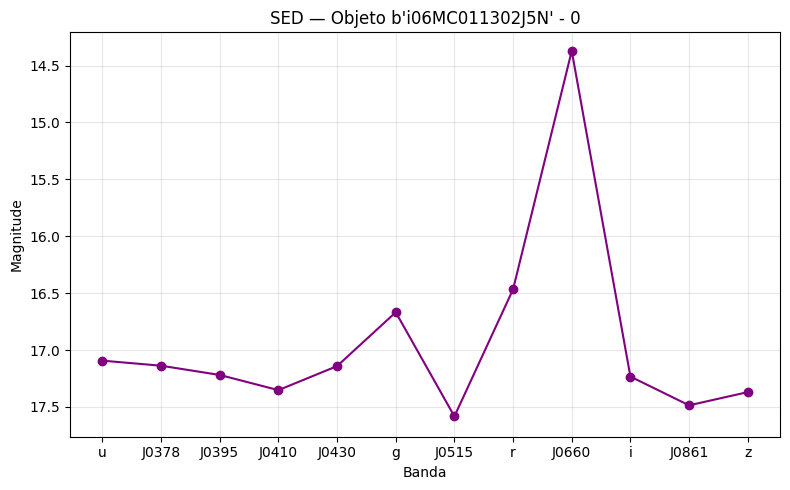

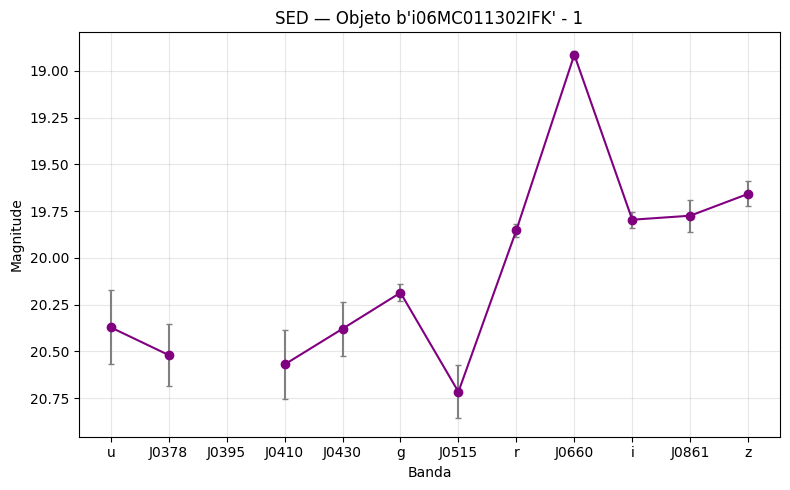

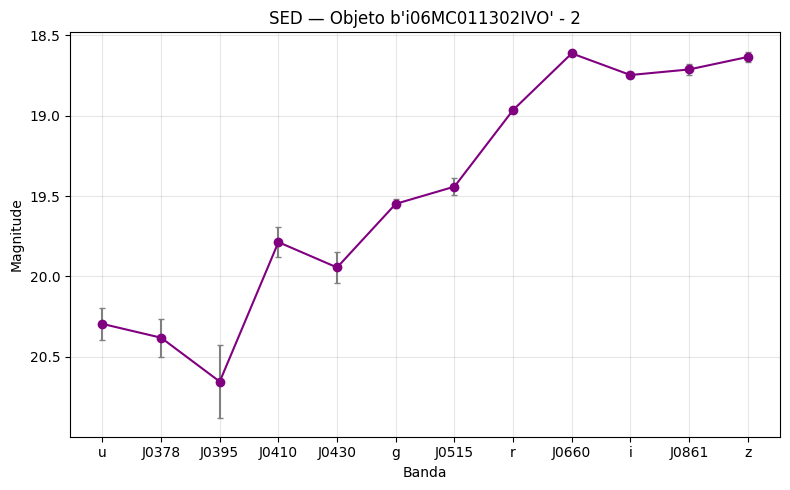

In [34]:
import numpy as np
import matplotlib.pyplot as plt

bands = ['u', 'J0378', 'J0395', 'J0410', 'J0430', 'g', 'J0515', 'r', 'J0660', 'i', 'J0861', 'z']
wavelengths = np.array([3536, 3770, 3940, 4094, 4292, 4751, 5133, 6258, 6614, 7690, 8611, 8831])

mag_cols = [f"star_mag_psf_{b.lower()}" for b in bands]
err_cols = [f"star_err_mag_psf_{b.lower()}" for b in bands]
has_errors = all(col in b3.columns for col in err_cols)

i = 0
for idx, row in b3.iterrows():
    mags = row[mag_cols].to_numpy()

    plt.figure(figsize=(8, 5))
    if has_errors:
        errs = row[err_cols].to_numpy()
        plt.errorbar(bands, mags, yerr=errs, fmt='o-', color='purple', ecolor='gray', capsize=2)
    else:
        plt.plot(bands, mags, 'o-', color='purple')

    plt.gca().invert_yaxis()
    plt.xlabel('Banda')
    plt.ylabel('Magnitude')
    plt.title(f'SED — Objeto {row["star_id"]} - {i}')  # <<< usar a linha atual
    # plt.title(f'SED — Objeto {row['id']} - {row['main_type']}')  # se quiser incluir o tipo

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    i += 1
    if i >= 50:
        break

In [91]:
import splusdata

bands = ['u', 'J0378', 'J0395', 'J0410', 'J0430', 'g', 'J0515', 'r', 'J0660', 'i', 'J0861', 'z']
mag_cols = [f"star_mag_psf_{b.lower()}" for b in bands]
err_cols = [f"star_err_mag_psf_{b.lower()}" for b in bands]

def get_splus_client():
    return splusdata.Core('marinaiza', 'Mari1407*')

def load_single_band_fits(client, ra, dec, size_arcsec=120, band="r", data_release="idr6"):
    hdu = client.stamp(
        ra=float(ra), dec=float(dec),
        size=size_arcsec, size_unit="arcsec",
        band=band, data_release=data_release
    )
    img = hdu[1].data
    wcs = WCS(hdu[1].header)
    return img, wcs

def pick_colors(n):
    cmap = plt.get_cmap("tab20")
    return [cmap(i % 20) for i in range(n)]


def plot_cluster_image_and_seds(
    b3,
    center_ra, center_dec,
    size_arcsec=120,
    ra_col="ra", dec_col="dec",
    id_col="star_id",
    data_release="idr6",
    image_band="r",
    limit= 10,
    aperture_col=None,
    aperture_unit="arcsec",
    aperture_is_diameter=False,
    aperture_alpha=0.9,
    aperture_lw=1.2,
    draw_center_dot=True
):
    
    bands = ['u', 'J0378', 'J0395', 'J0410', 'J0430', 'g', 'J0515', 'r', 'J0660', 'i', 'J0861', 'z']
    wavelengths = np.array([3536, 3770, 3940, 4094, 4292, 4751, 5133, 6258, 6614, 7690, 8611, 8831])

    mag_cols = [f"star_mag_psf_{b.lower()}" for b in bands]
    err_cols = [f"star_err_mag_psf_{b.lower()}" for b in bands]
    has_errors = all(col in b3.columns for col in err_cols)

    # Select stars with finite magnitudes
    valid = b3[mag_cols].applymap(np.isfinite).all(axis=1)
    stars = b3[valid].copy().head(limit).reset_index(drop=True)
    if len(stars) == 0:
        raise ValueError("No stars with valid magnitudes")

    colors = pick_colors(len(stars))
    client = get_splus_client()
    img, wcs = load_single_band_fits(client, center_ra, center_dec,
                                     size_arcsec, image_band, data_release)

    # Pixel scale (arcsec/pixel)
    pix_scales_deg = proj_plane_pixel_scales(wcs)   # (dy, dx) in deg/pix
    arcsec_per_pix_y, arcsec_per_pix_x = pix_scales_deg * 3600.0
    arcsec_per_pix = float((arcsec_per_pix_x + arcsec_per_pix_y) / 2.0)

    # --- calcular offsets em arcsec em torno do centro ---
    ny, nx = img.shape
    x0_pix, y0_pix = wcs.world_to_pixel_values(center_ra, center_dec)

    # array de coordenadas em arcsec para os limites da imagem
    x_edges_pix = np.array([0, nx - 1])
    y_edges_pix = np.array([0, ny - 1])

    x_edges_arcsec = (x_edges_pix - x0_pix) * arcsec_per_pix
    y_edges_arcsec = (y_edges_pix - y0_pix) * arcsec_per_pix

    extent = [x_edges_arcsec[0], x_edges_arcsec[1],
              y_edges_arcsec[0], y_edges_arcsec[1]]

    # ---------- Figure ----------
    fig = plt.figure(figsize=(13, 6), dpi=120)
    gs = GridSpec(nrows=1, ncols=2, figure=fig,
                  width_ratios=[1.2, 1.0], wspace=0.2)

    # ---------- Left: image em offsets angulares ----------
    vmin = np.percentile(img, 1)
    vmax = np.percentile(img, 99)

    # sem projection=wcs agora
    ax_img = fig.add_subplot(gs[0, 0])
    ax_img.imshow(img, origin="lower", cmap="gray",
                  vmin=vmin, vmax=vmax, extent=extent)
    ax_img.set_xlabel(r"ΔRA (arcsec)")
    ax_img.set_ylabel(r"ΔDec (arcsec)")
    ax_img.grid(alpha=0.2, color="white", ls=":")

    # Plot stars + apertures
    for i, row in stars.iterrows():
        print(f"Plotting star {i+1}/{len(stars)}: ID={row[id_col]}")
        ra = float(row[ra_col])
        dec = float(row[dec_col])

        # RA,Dec -> pixel
        xpix, ypix = wcs.world_to_pixel_values(ra, dec)

        # pixel -> offset em arcsec relativo ao centro
        x_arcsec = (xpix - x0_pix) * arcsec_per_pix
        y_arcsec = (ypix - y0_pix) * arcsec_per_pix

        # marcador da estrela
        if draw_center_dot:
            ax_img.scatter(
                x_arcsec, y_arcsec,
                s=30, facecolors='none', edgecolors=colors[i],
                linewidths=1.5, zorder=3
            )

        # círculo de abertura em arcsec
        if aperture_col is not None and aperture_col in row.index and np.isfinite(row[aperture_col]):
            aper_val = float(row[aperture_col])
            if aperture_is_diameter:
                aper_val *= 0.5  # vira raio

            unit = aperture_unit.lower()
            if unit in ("arcmin", "amin"):
                radius_arcsec = aper_val * 60.0
            elif unit in ("arcsec", "asec"):
                radius_arcsec = aper_val
            elif unit in ("pix", "pixel", "pixels"):
                radius_arcsec = aper_val * arcsec_per_pix
            else:
                raise ValueError(
                    "aperture_unit must be one of: 'arcsec', 'arcmin', 'pix', 'pixel', 'pixels'."
                )

            # circ = Circle(
            #     (x_arcsec, y_arcsec), radius_arcsec,
            #     fill=False, lw=aperture_lw, alpha=aperture_alpha,
            #     edgecolor=colors[i], zorder=3
            # )
            # ax_img.add_patch(circ)

    # Cluster center marker em (0,0) arcsec
    ax_img.scatter(
        0.0, 0.0,
        s=60, marker='+', color='yellow',
        linewidths=1.8, zorder=4, label='Center'
    )

    # ---------- Right: SED (igual ao seu) ----------
    ax_sed = fig.add_subplot(gs[0, 1])
    x = np.arange(len(bands))
    has_errors = all(c in b3.columns for c in err_cols)

    for i, row in stars.iterrows():
        mags = row[mag_cols].to_numpy(dtype=float)
        label = str(row[id_col]) if id_col in row.index else f"obj {i+1}"
        if has_errors:
            errs = row[err_cols].to_numpy(dtype=float)
            ax_sed.errorbar(x, mags, yerr=errs, fmt='o-',
                            color=colors[i], lw=1.2, capsize=2, label=label)
        else:
            ax_sed.plot(x, mags, 'o-', color=colors[i],
                        lw=1.2, label=label)

    ax_sed.set_xticks(x)
    ax_sed.set_xticklabels(bands, rotation=45,
                           ha='right', fontsize=9)
    ax_sed.invert_yaxis()
    ax_sed.set_ylabel("Magnitude")
    ax_sed.set_xlabel("Band")
    ax_sed.grid(alpha=0.3)
    ax_sed.legend(fontsize=8, title="Stars",
                  title_fontsize=9, loc="best")

    fig.suptitle(
        f"S-PLUS {image_band}-band stamp (ΔRA/ΔDec in arcsec)  |  SEDs (N={len(stars)})",
        y=0.98
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    plt.close(fig)

/tmp/ipykernel_8090/1395860479.py:50: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  valid = b3[mag_cols].applymap(np.isfinite).all(axis=1)


Plotting star 1/2: ID=i06MC011302J5N
Plotting star 2/2: ID=i06MC011302IVO


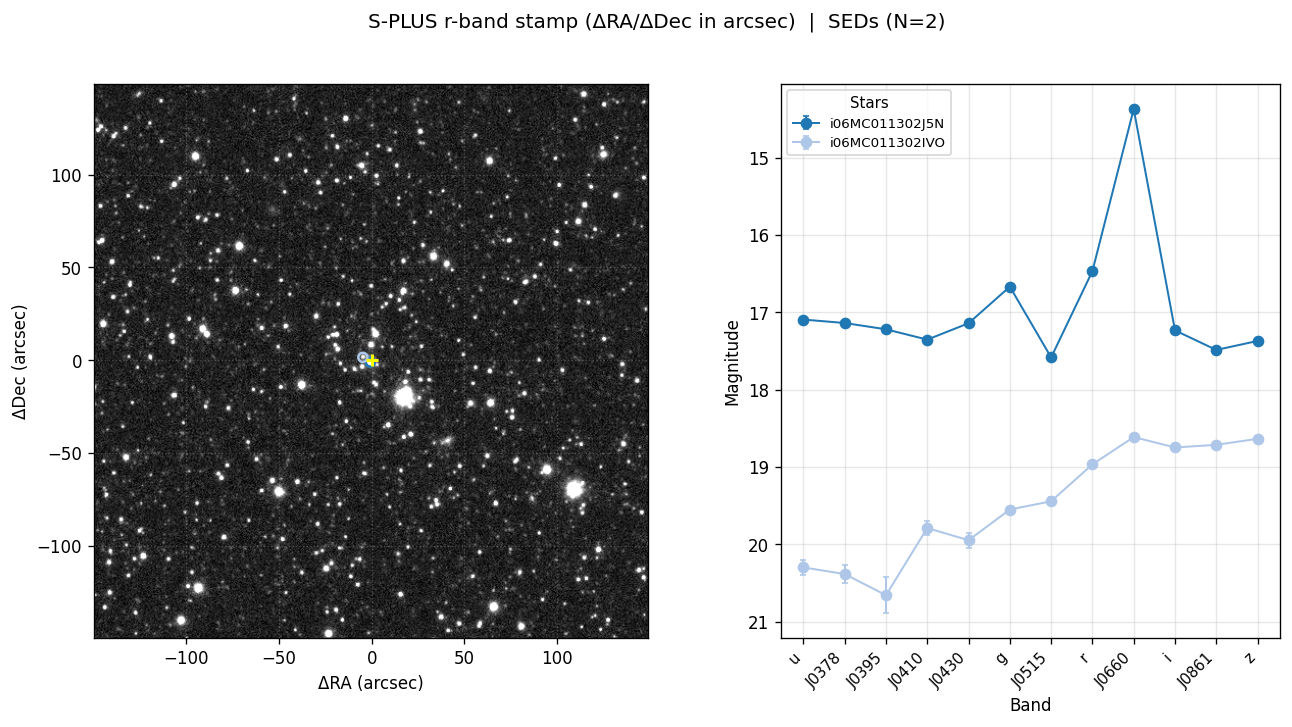

PlanetaryNebula 2.0 0.043488372 0.6744186


In [ ]:
center_ra  = float(b3['cluster_ra_deg'].iloc[0])
center_dec = float(b3['cluster_dec_deg'].iloc[0])

plot_cluster_image_and_seds(
    b3, center_ra, center_dec,
    size_arcsec=300,
    ra_col="star_ra", dec_col="star_dec",
    id_col="star_id",
    data_release="idr6",
    image_band="r",
    limit=20,
    aperture_col="cluster_amaj",    # <-- per-star radius column
    aperture_unit="arcmin",          # values are in arcminutes
    aperture_is_diameter=True,      # set True if your column is a diameter
)

#ajuste melhor esse print

print(b3['star_classlabel_espels'].iloc[0], 
      b3['star_classlabel_espels_flag'].iloc[0], 
      b3['star_classprob_espels_bestar'].iloc[0], 
      b3['star_classprob_espels_pne'].iloc[0])

/tmp/ipykernel_6343/2406930639.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  valid = b3[mag_cols].applymap(np.isfinite).all(axis=1)


Plotting star 1/1: ID=b'i06MC013302NQP'


/tmp/ipykernel_6343/2406930639.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


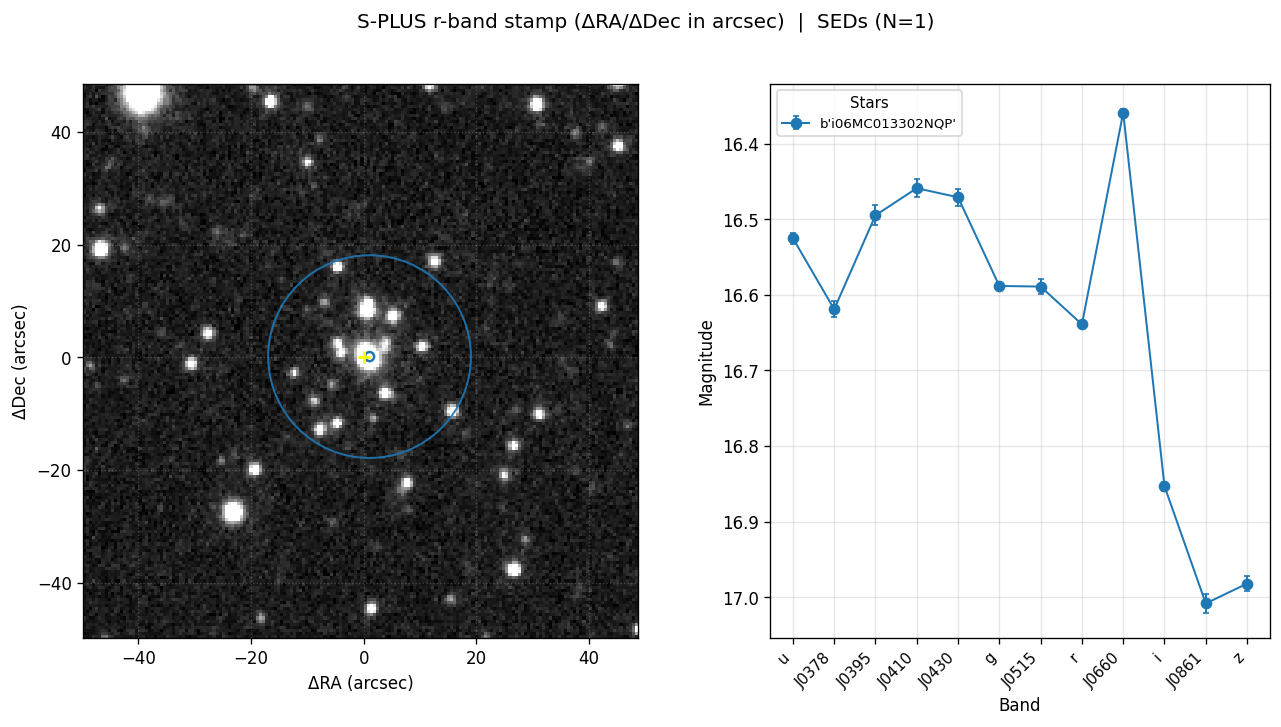

In [33]:
center_ra  = float(b6['cluster_ra_deg'].iloc[0])
center_dec = float(b6['cluster_dec_deg'].iloc[0])

plot_cluster_image_and_seds(
    b6, center_ra, center_dec,
    size_arcsec=100,
    ra_col="star_ra", dec_col="star_dec",
    id_col="star_id",
    data_release="idr6",
    image_band="r",
    limit=20,
    aperture_col="cluster_amaj",    # <-- per-star radius column
    aperture_unit="arcmin",          # values are in arcminutes
    aperture_is_diameter=True,      # set True if your column is a diameter
)

In [29]:
hw2 = out[out['cluster_Names'] == 'HW2                                    ']
hw2



,cluster_index,star_index,sep_arcsec,sep_arcmin,cluster_ra_deg,cluster_dec_deg,cluster_amaj,cluster_Names,star_ra,star_dec,...,star_mag_psf_j0395,star_mag_psf_j0410,star_mag_psf_j0430,star_mag_psf_g,star_mag_psf_j0515,star_mag_psf_r,star_mag_psf_j0660,star_mag_psf_i,star_mag_psf_j0861,star_mag_psf_z
70,3133,9851,1.416603,0.023610,6.987083,-74.001111,0.95,HW2,6.985787,-74.000946,...,18.879057,18.751524,18.615591,18.467764,18.282920,17.980234,17.729683,17.720509,17.493849,17.461987
3990,3133,3038,28.373360,0.472889,6.987083,-74.001111,0.95,HW2,6.973319,-74.008020,...,15.160406,15.234369,15.286059,15.405728,15.386243,15.445659,15.209139,15.586363,15.827524,15.823598
4031,3133,1001,28.538427,0.475640,6.987083,-74.001111,0.95,HW2,6.973642,-74.008120,...,15.191854,15.220327,15.270093,15.393486,15.387080,15.449656,15.186580,15.576020,15.824592,15.838327
4099,3133,9849,28.951128,0.482519,6.987083,-74.001111,0.95,HW2,6.973235,-74.008190,...,15.225813,15.279203,15.267191,15.426265,15.411190,15.478636,15.227413,15.603044,15.823457,15.834373


/tmp/ipykernel_6343/304904128.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  valid = b3[mag_cols].applymap(np.isfinite).all(axis=1)


Plotting star 1/4: ID=b'i06MC011401D1E'
Plotting star 2/4: ID=b'i06MC013304FCV'
Plotting star 3/4: ID=b'i06MC011300OMJ'
Plotting star 4/4: ID=b'i06MC0114019KX'


/tmp/ipykernel_6343/304904128.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


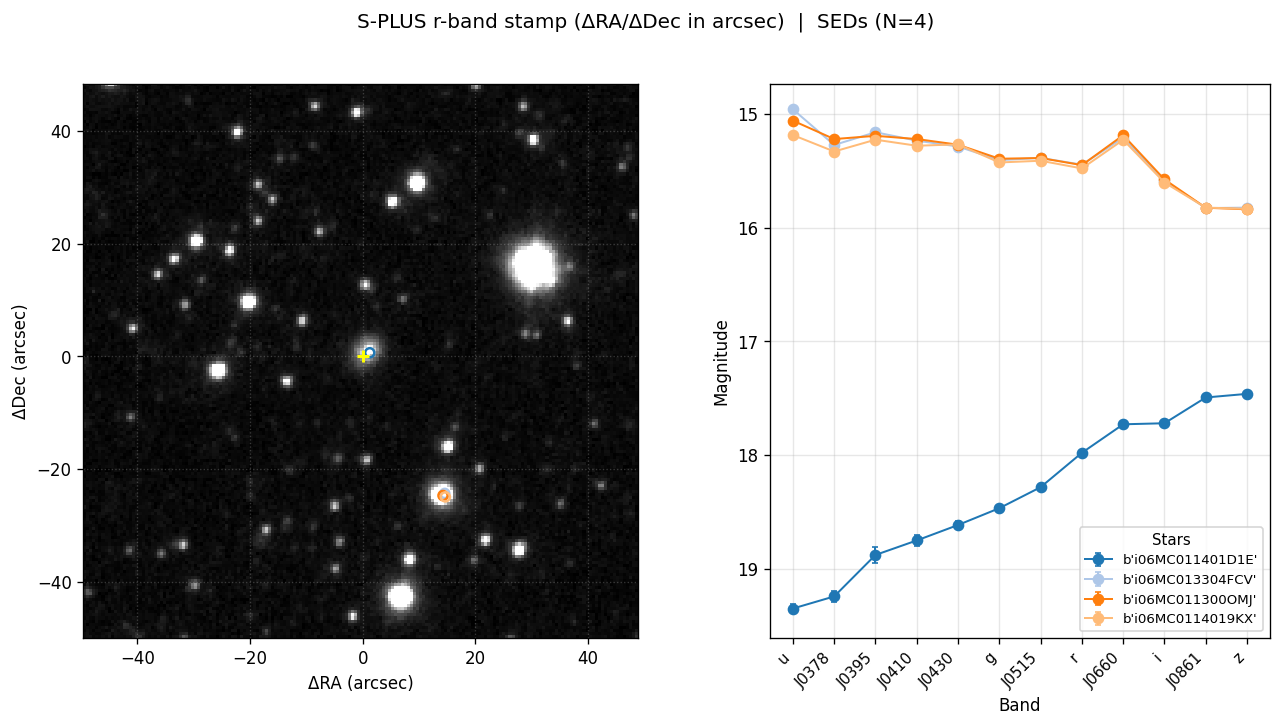

In [40]:
center_ra  = float(hw2['cluster_ra_deg'].iloc[0])
center_dec = float(hw2['cluster_dec_deg'].iloc[0])

plot_cluster_image_and_seds(
    hw2, center_ra, center_dec,
    size_arcsec=100,
    ra_col="star_ra", dec_col="star_dec",
    id_col="star_id",
    data_release="idr6",
    image_band="r",
    limit=20,
    aperture_col="cluster_amaj",    # <-- per-star radius column
    aperture_unit="arcmin",          # values are in arcminutes
    aperture_is_diameter=True,      # set True if your column is a diameter
)

In [41]:
bica1 = out[out['cluster_Names'] == 'BS I,Bica-Schmitt I                    ']
bica1

,cluster_index,star_index,sep_arcsec,sep_arcmin,cluster_ra_deg,cluster_dec_deg,cluster_amaj,cluster_Names,star_ra,star_dec,...,star_mag_psf_j0395,star_mag_psf_j0410,star_mag_psf_j0430,star_mag_psf_g,star_mag_psf_j0515,star_mag_psf_r,star_mag_psf_j0660,star_mag_psf_i,star_mag_psf_j0861,star_mag_psf_z
9369,5736,18816,76.786006,1.279767,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",31.973112,-74.43748,...,13.718497,13.185256,13.128447,12.734455,12.606196,12.307721,12.252529,12.385682,12.165252,12.160000
17374,5736,18819,189.700076,3.161668,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",32.072346,-74.39390,...,15.544681,15.564976,15.606739,15.693672,15.735846,15.869580,15.640634,16.063890,16.261196,16.272860
18039,5736,18817,203.302613,3.388377,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",31.913400,-74.40224,...,16.939173,16.936700,16.954601,17.040033,17.093096,17.170261,16.935402,17.379133,17.539260,17.577736
18773,5736,18814,226.499838,3.774997,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",32.243880,-74.41246,...,17.035220,16.985079,17.014406,17.139692,17.217192,17.380962,17.325367,17.608025,17.763765,17.851694
19821,5736,18815,261.136954,4.352283,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",32.281204,-74.41048,...,16.638187,16.637846,16.648817,16.761658,16.797306,16.922565,16.693134,17.104740,17.320362,17.349552
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30289,5736,23634,7166.851852,119.447531,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",28.820267,-72.67620,...,17.262962,16.632736,16.570543,16.086231,15.926118,15.439963,15.313627,15.257951,15.111448,15.161289
30290,5736,44935,7167.639687,119.460661,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",24.610338,-74.66871,...,19.064184,18.614532,18.590887,18.384180,18.233480,18.028656,17.848630,17.958683,17.865513,17.952934
30291,5736,19322,7170.852849,119.514214,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",25.458641,-73.61607,...,17.450663,17.416380,17.501831,17.597002,17.618940,17.801926,17.721510,18.059685,18.162312,18.225597
30292,5736,695,7185.245890,119.754098,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",39.500270,-74.47616,...,14.333851,13.725114,13.623662,13.208361,13.017140,12.726866,12.662266,12.619847,12.521900,12.547705


/tmp/ipykernel_6343/760978232.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  valid = b3[mag_cols].applymap(np.isfinite).all(axis=1)


Plotting star 1/20: ID=b'i06MC0138015NJ'
Plotting star 2/20: ID=b'i06MC0138016OD'
Plotting star 3/20: ID=b'i06MC01380162N'
Plotting star 4/20: ID=b'i06MC0138015BU'
Plotting star 5/20: ID=b'i06MC0138015GW'
Plotting star 6/20: ID=b'i06MC0138013JA'
Plotting star 7/20: ID=b'i06MC01380106O'
Plotting star 8/20: ID=b'i06MC0138016OE'
Plotting star 9/20: ID=b'i06MC01380135T'
Plotting star 10/20: ID=b'i06MC0138019K2'
Plotting star 11/20: ID=b'i06MC0138010E0'
Plotting star 12/20: ID=b'i06MC0138014FL'
Plotting star 13/20: ID=b'i06MC013801A0J'
Plotting star 14/20: ID=b'i06MC013801AHT'
Plotting star 15/20: ID=b'i06MC013800ZDQ'
Plotting star 16/20: ID=b'i06MC0138018J8'
Plotting star 17/20: ID=b'i06MC013800X4S'
Plotting star 18/20: ID=b'i06MC01380192B'
Plotting star 19/20: ID=b'i06MC0138019CZ'
Plotting star 20/20: ID=b'i06MC013801BTB'


/tmp/ipykernel_6343/760978232.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


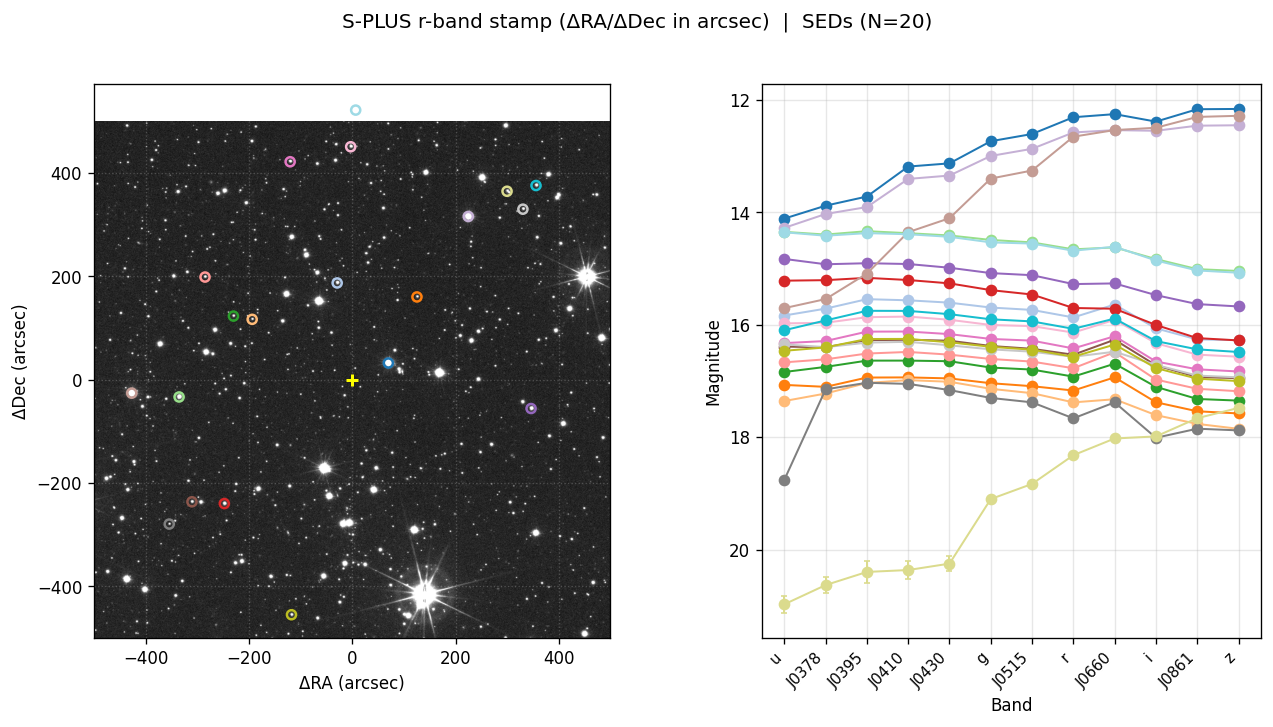

In [48]:
center_ra  = float(bica1['cluster_ra_deg'].iloc[0])
center_dec = float(bica1['cluster_dec_deg'].iloc[0])

plot_cluster_image_and_seds(
    bica1, center_ra, center_dec,
    size_arcsec=1000,
    ra_col="star_ra", dec_col="star_dec",
    id_col="star_id",
    data_release="idr6",
    image_band="r",
    limit=20,
    aperture_col="cluster_amaj",    # <-- per-star radius column
    aperture_unit="arcmin",          # values are in arcminutes
    aperture_is_diameter=True,      # set True if your column is a diameter
)

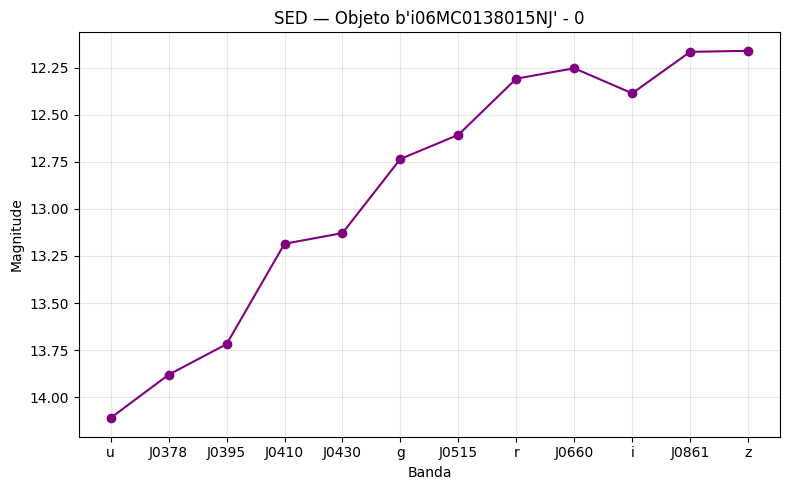

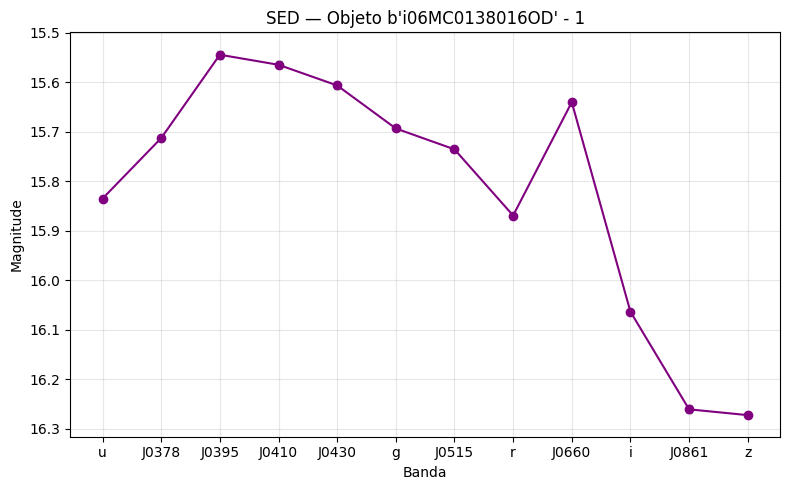

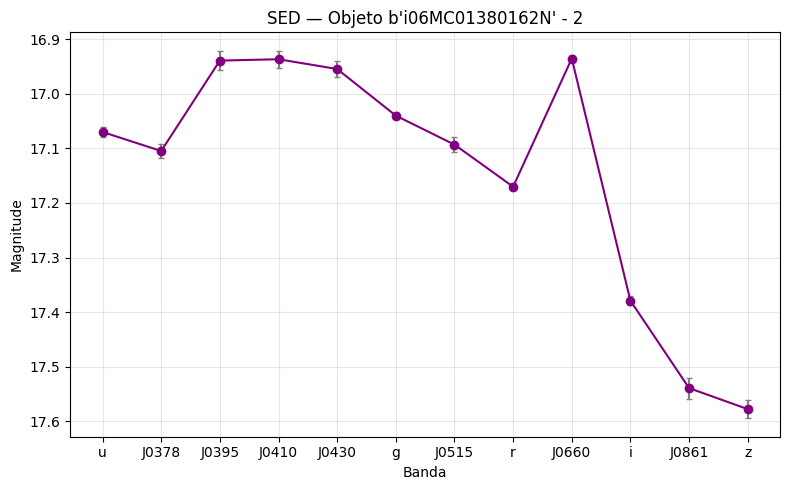

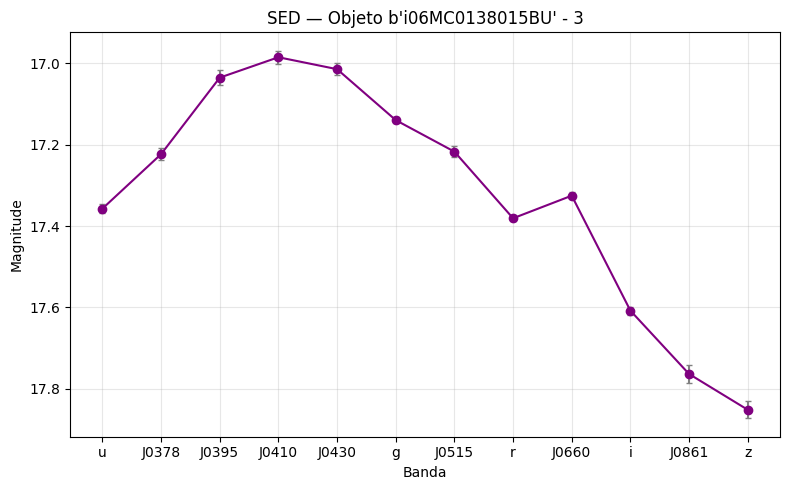

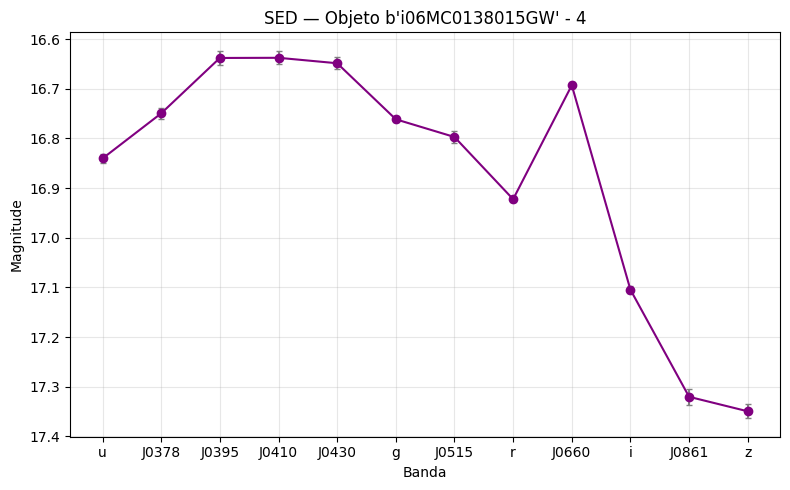

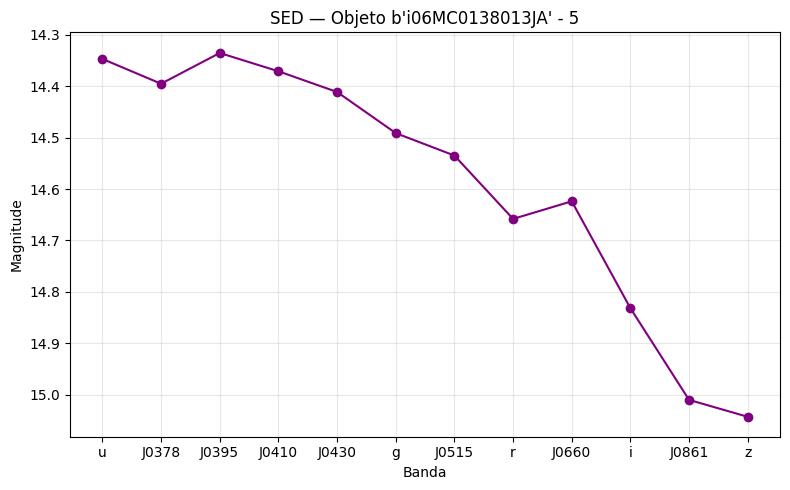

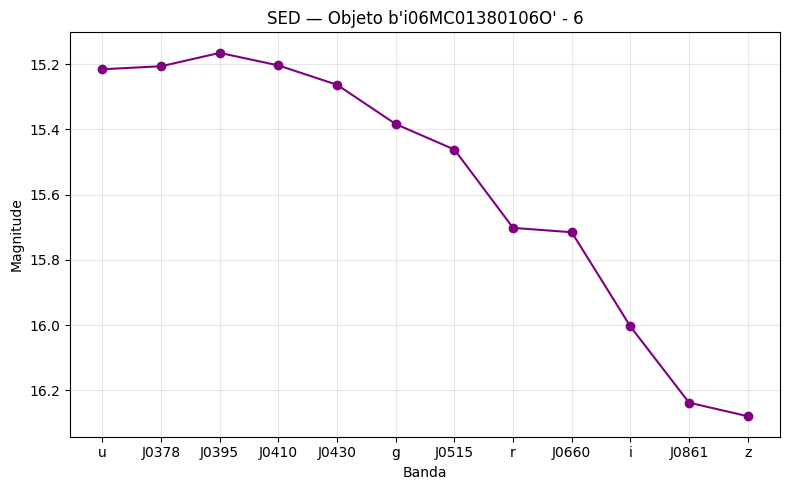

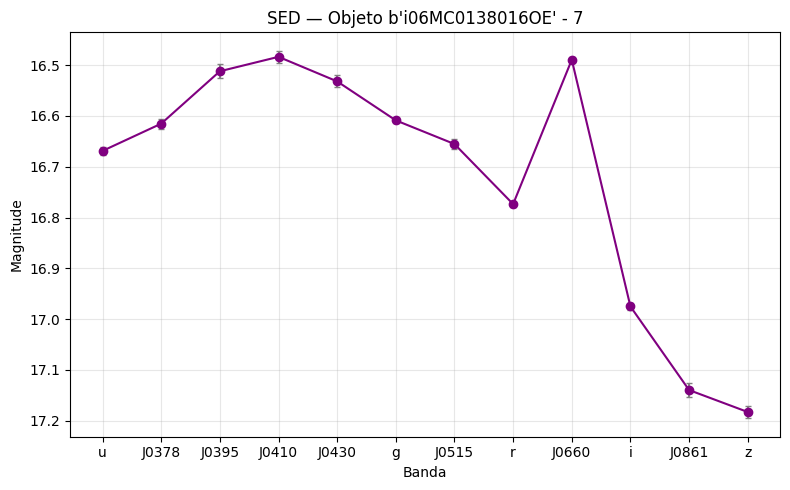

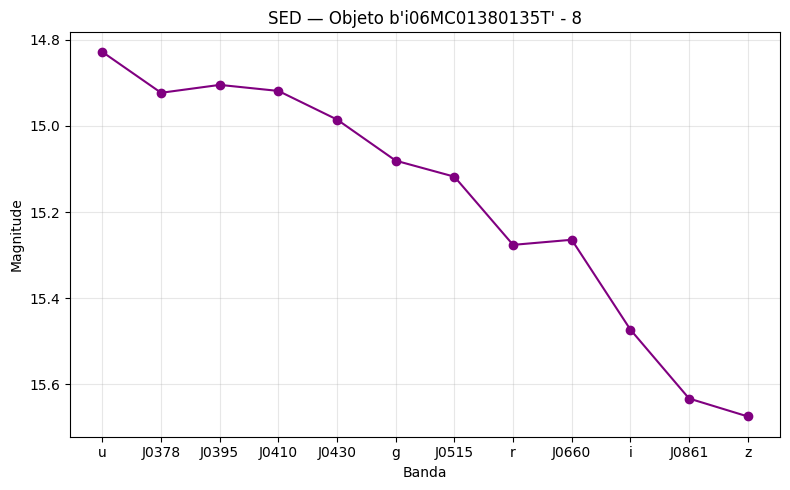

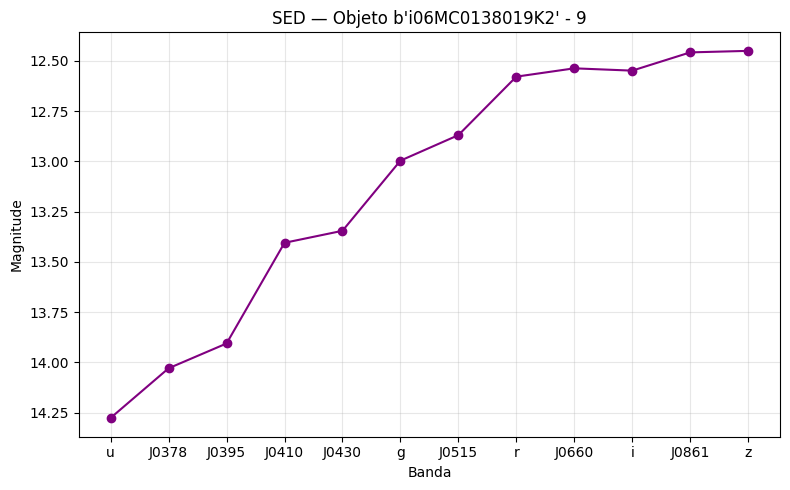

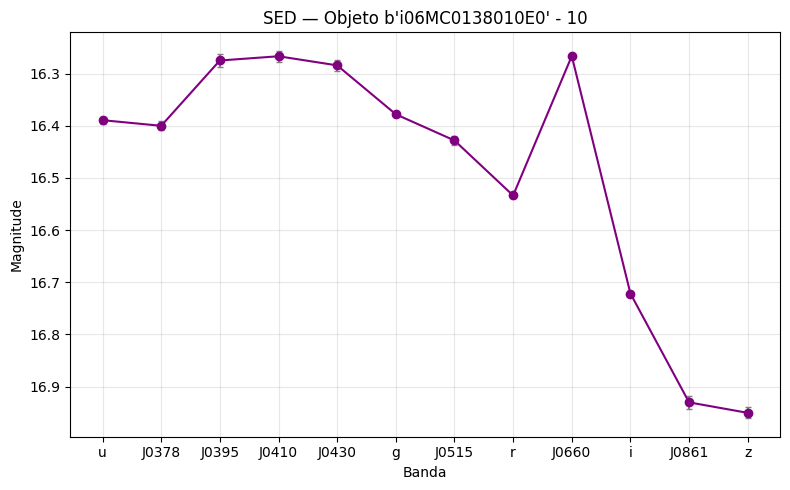

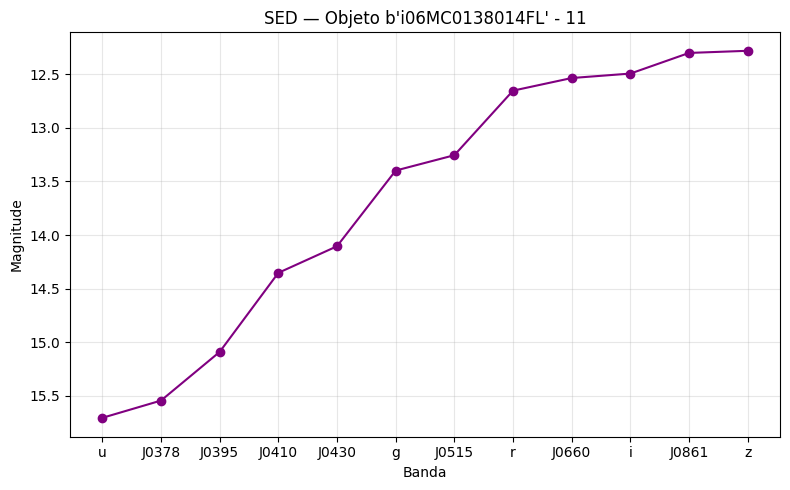

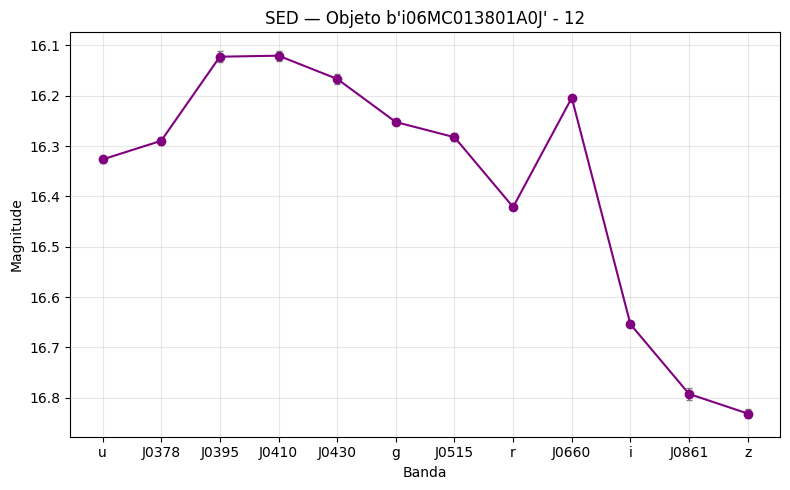

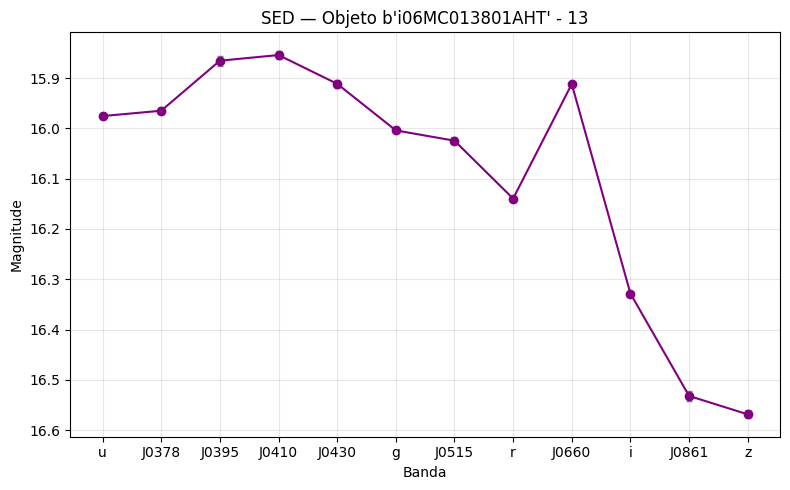

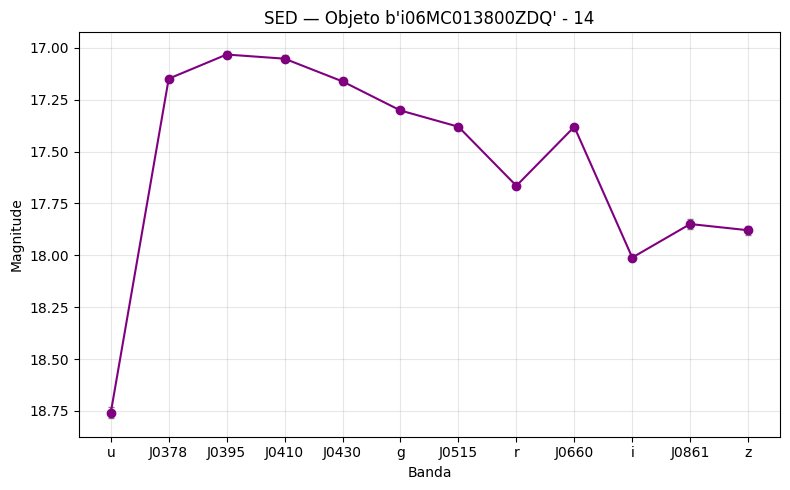

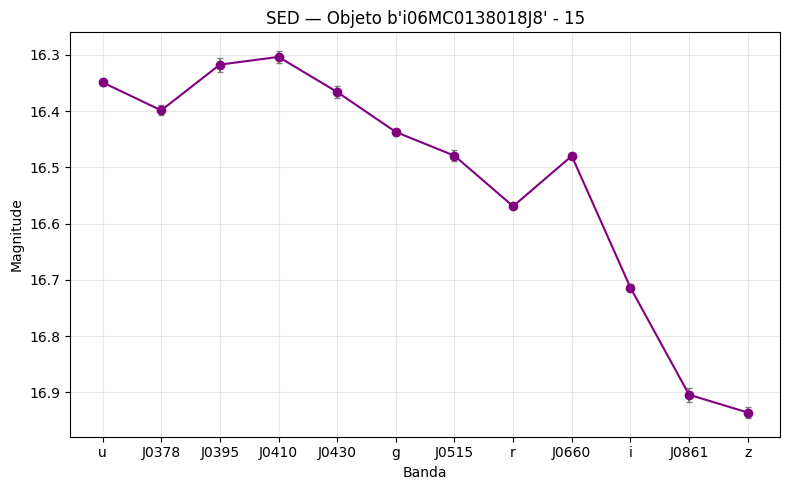

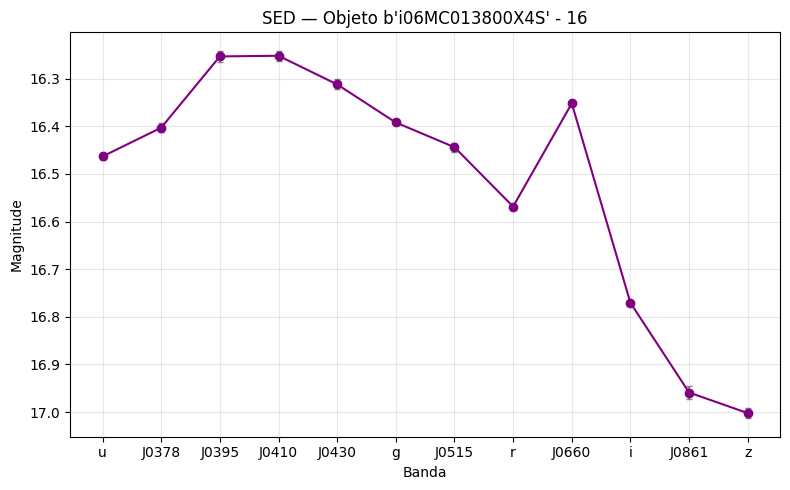

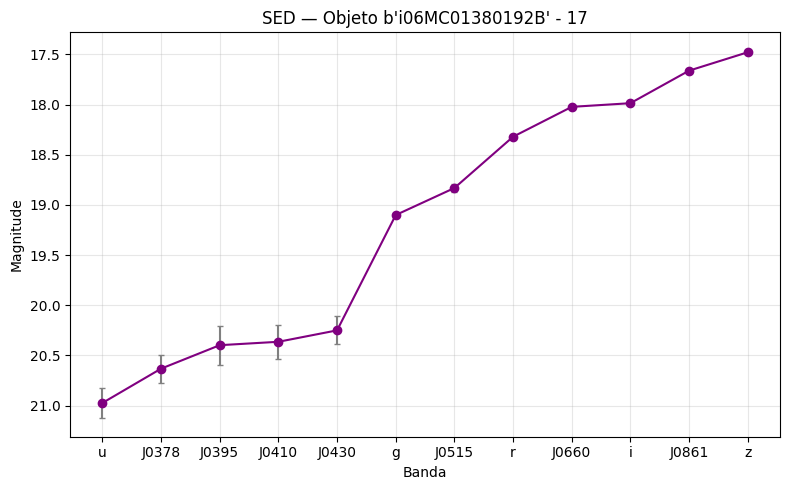

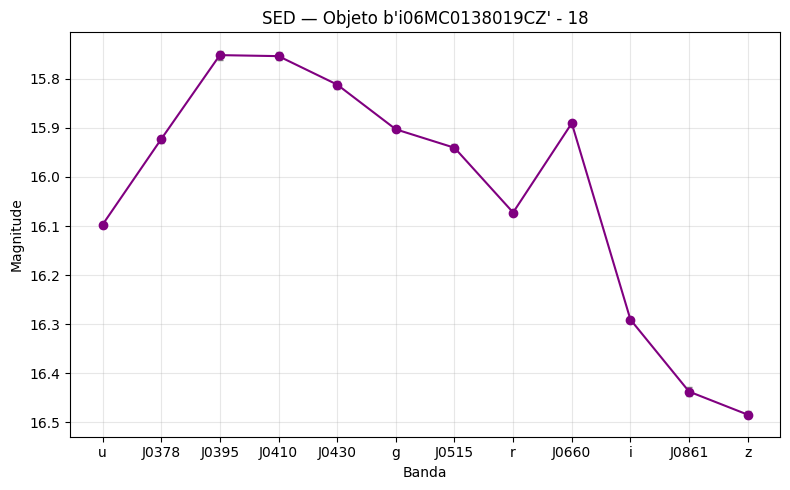

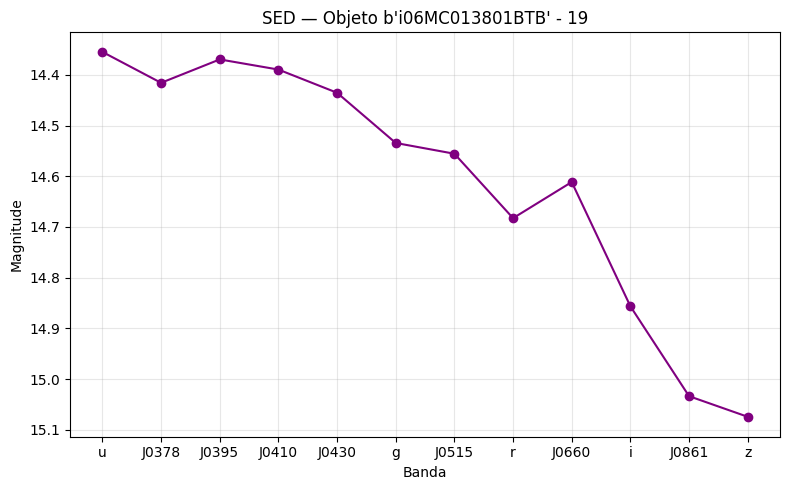

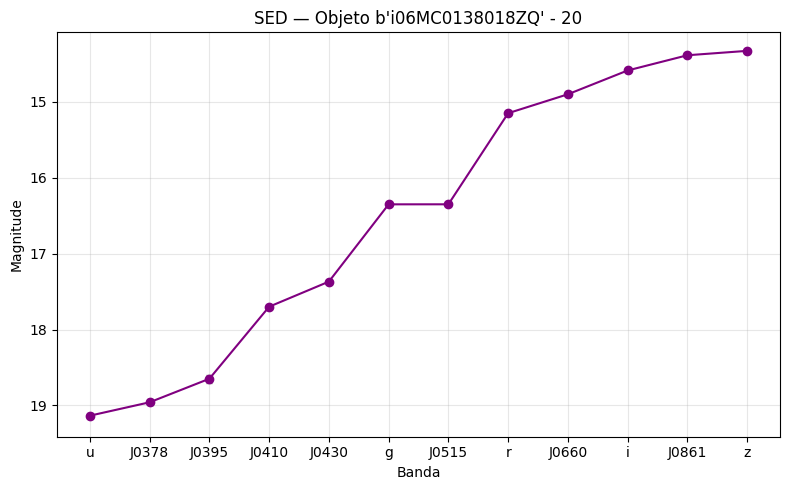

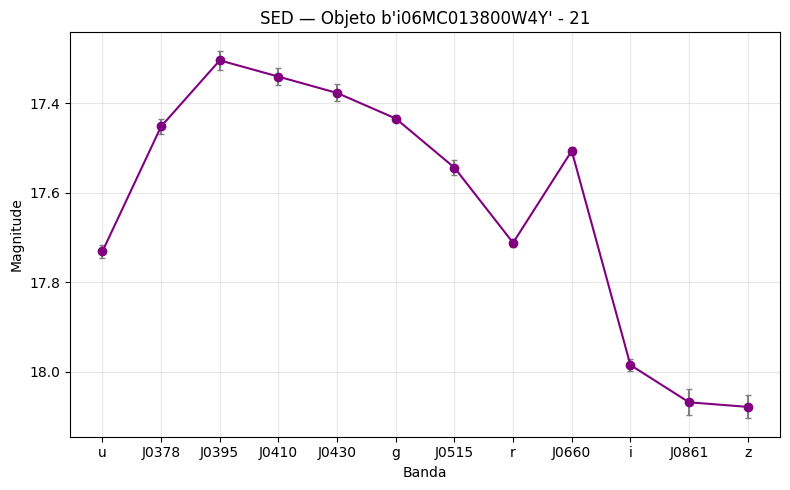

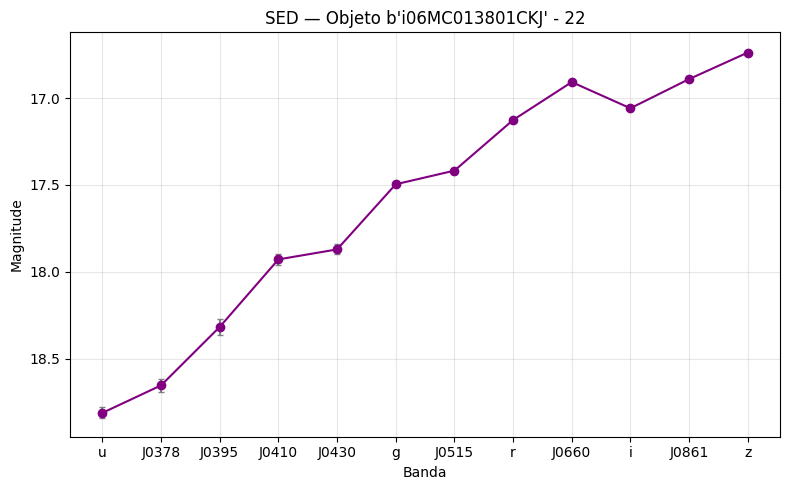

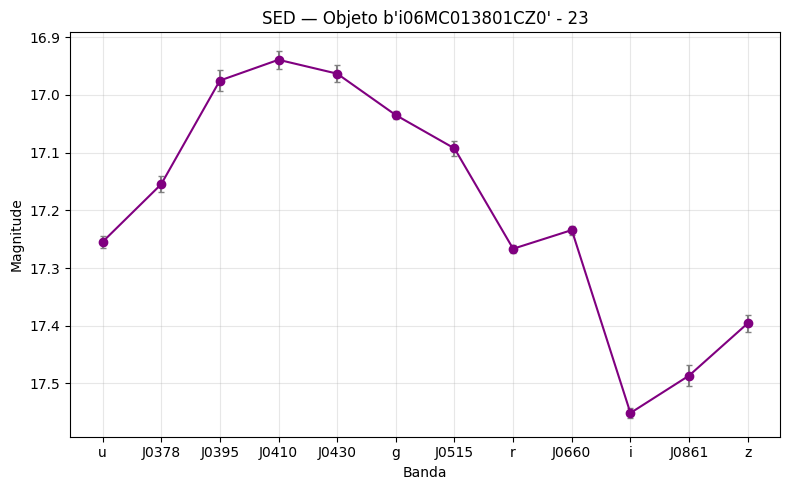

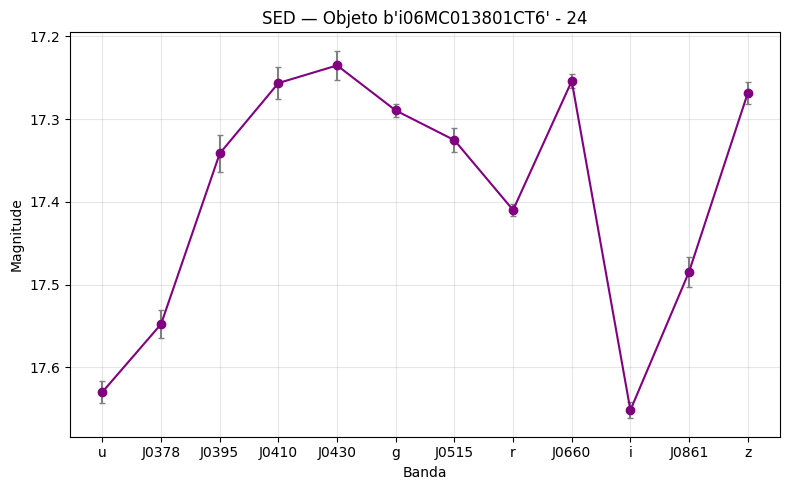

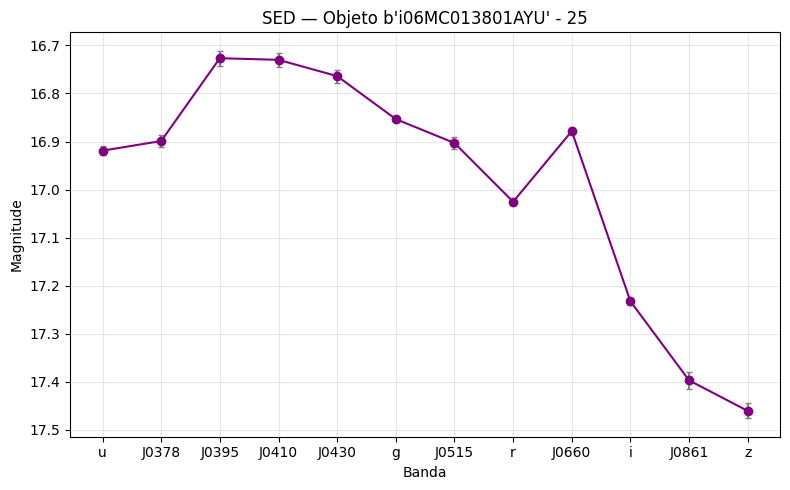

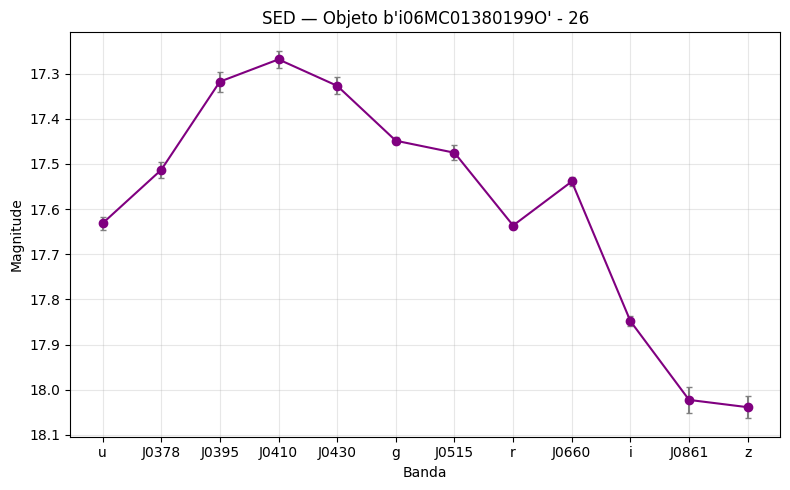

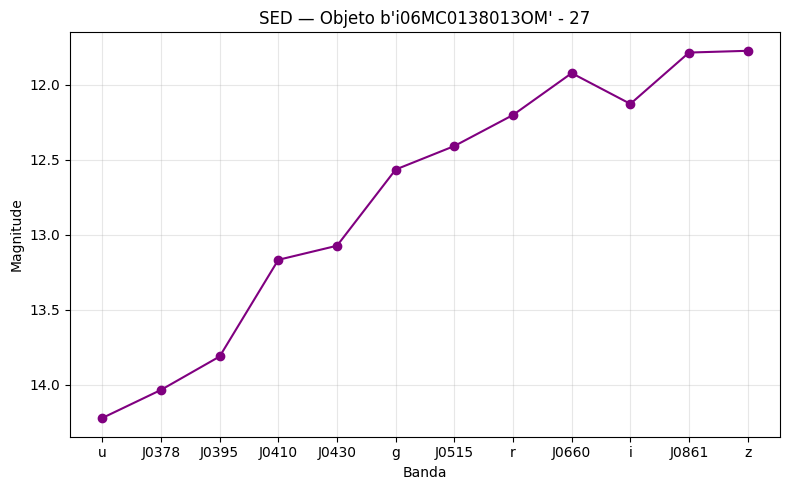

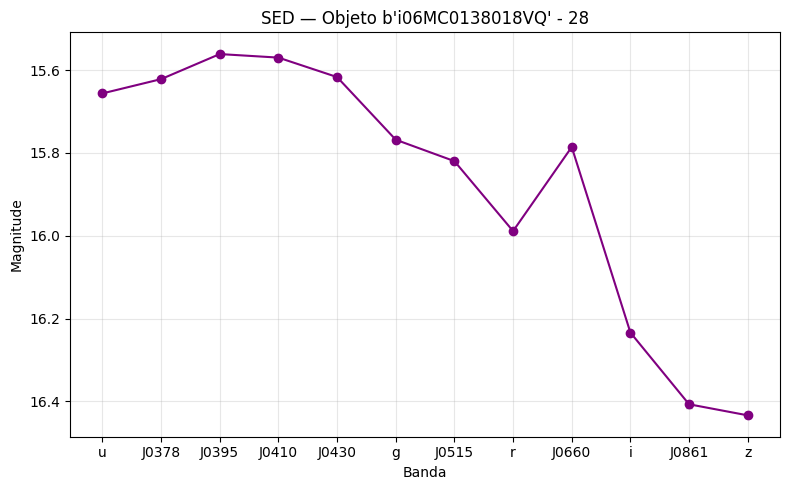

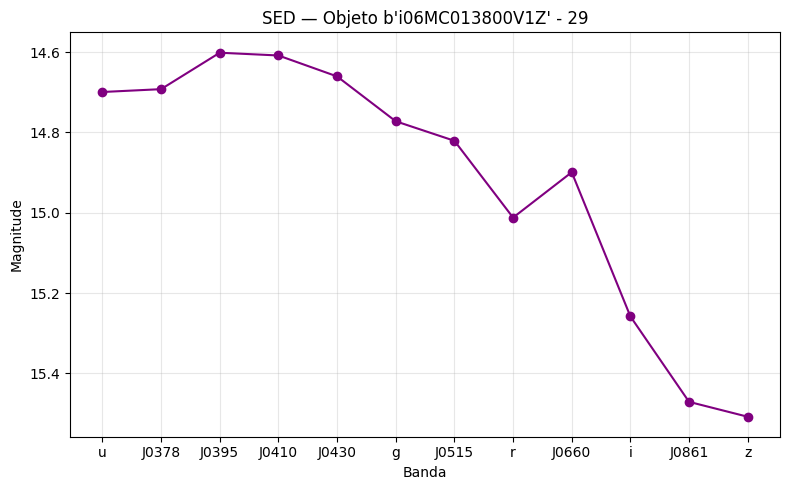

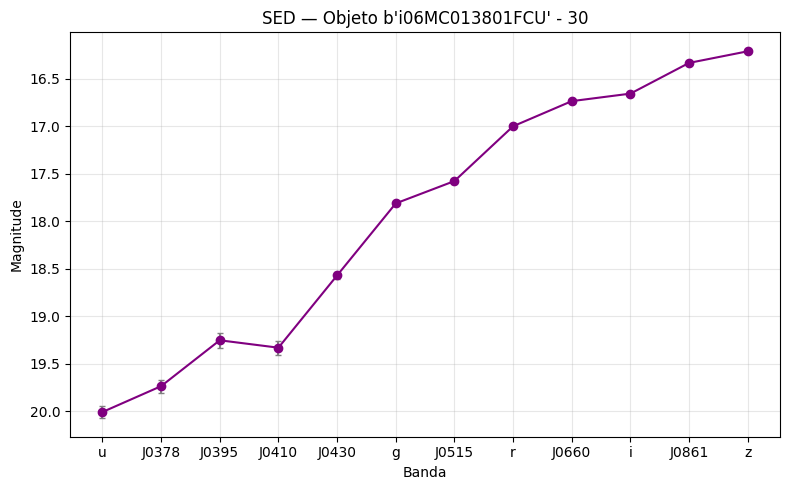

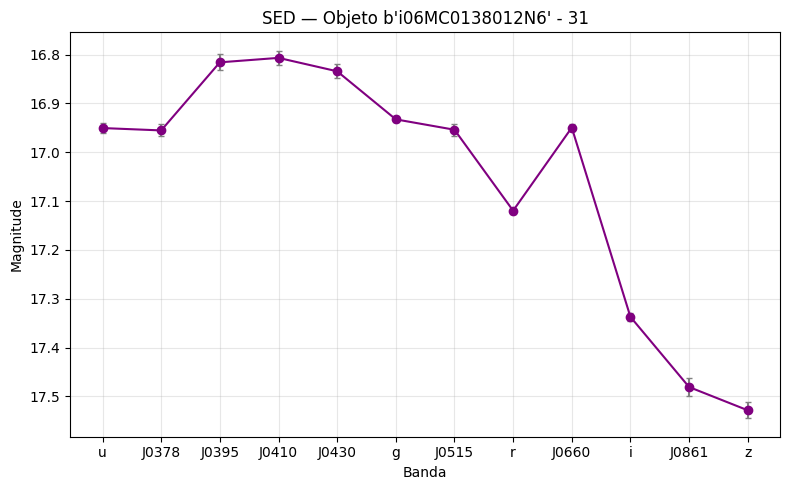

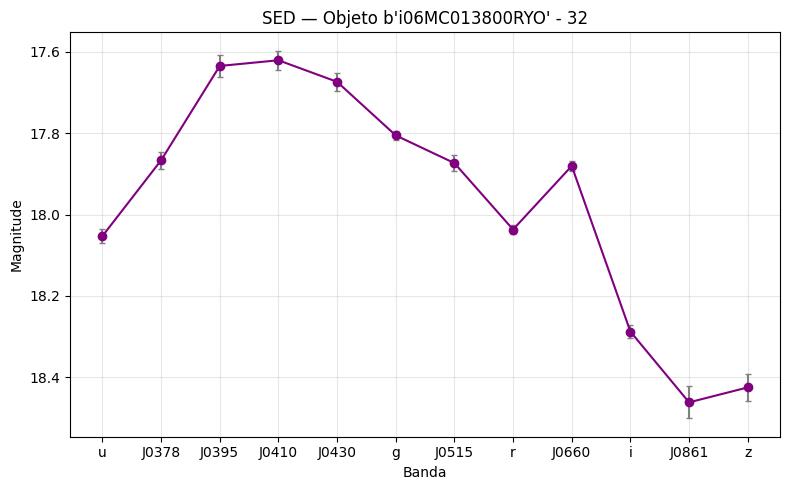

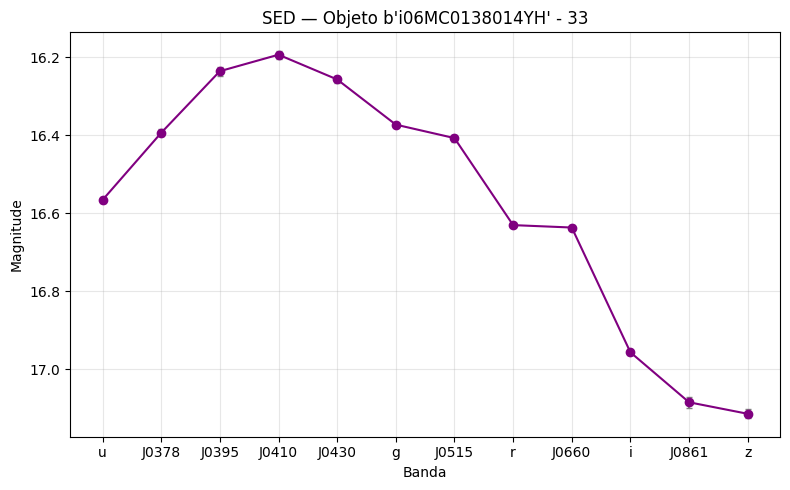

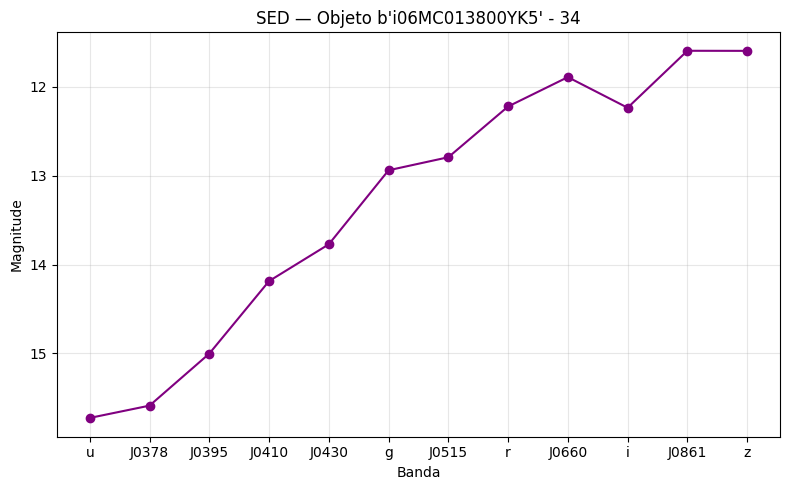

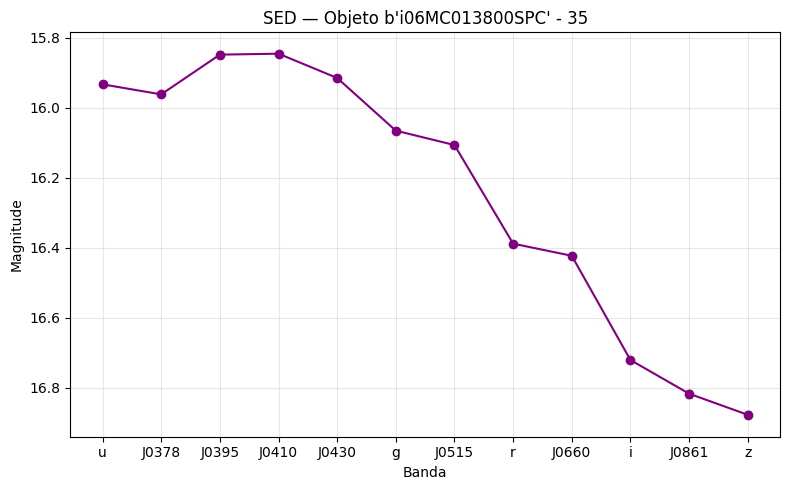

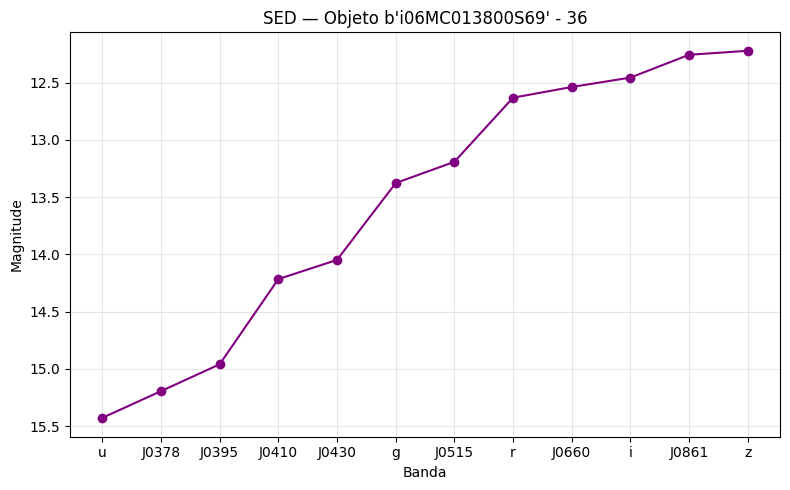

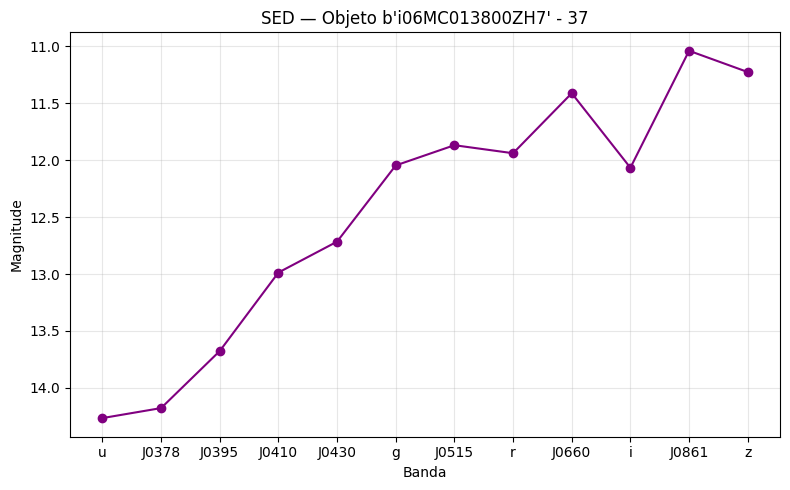

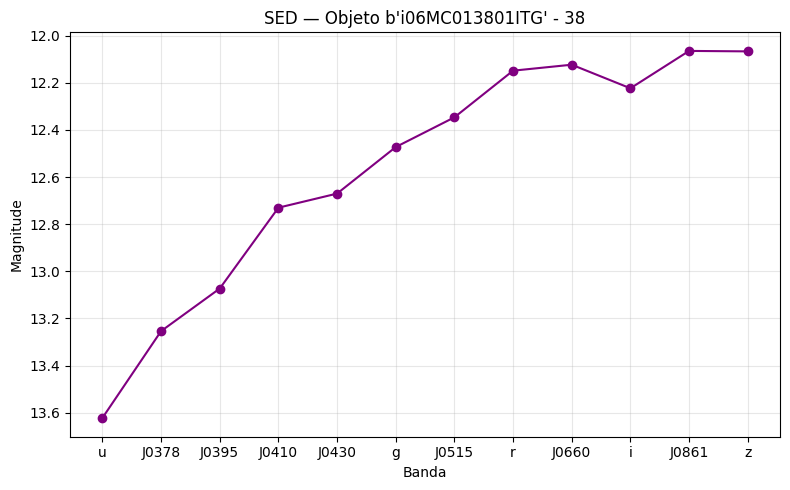

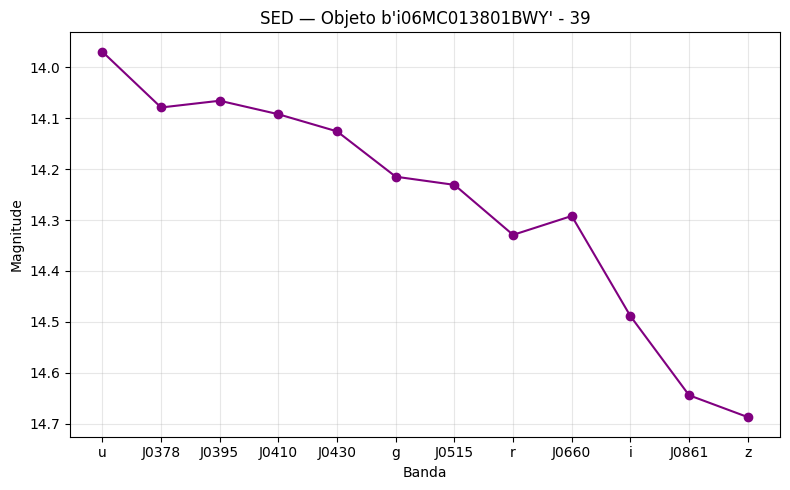

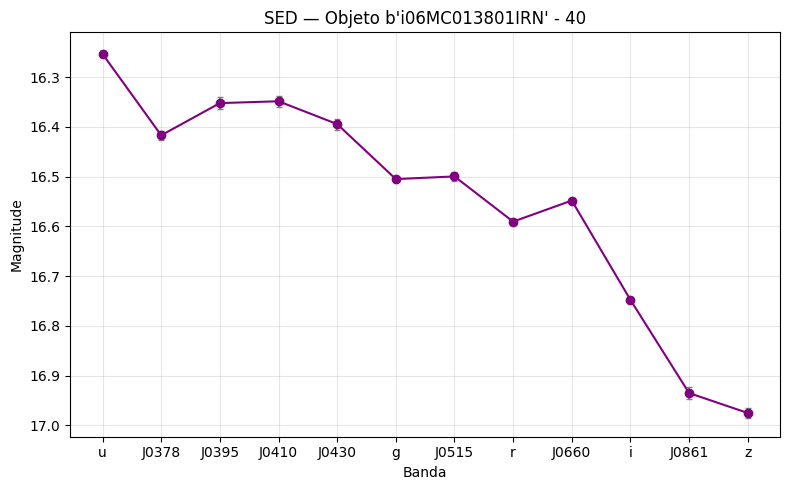

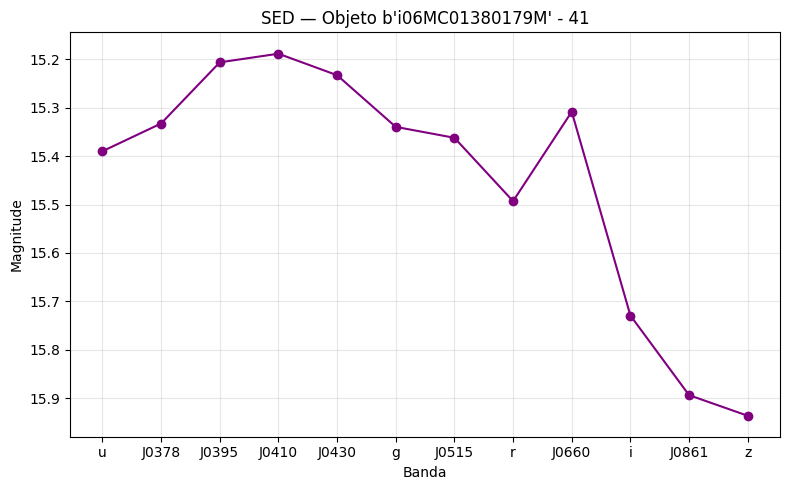

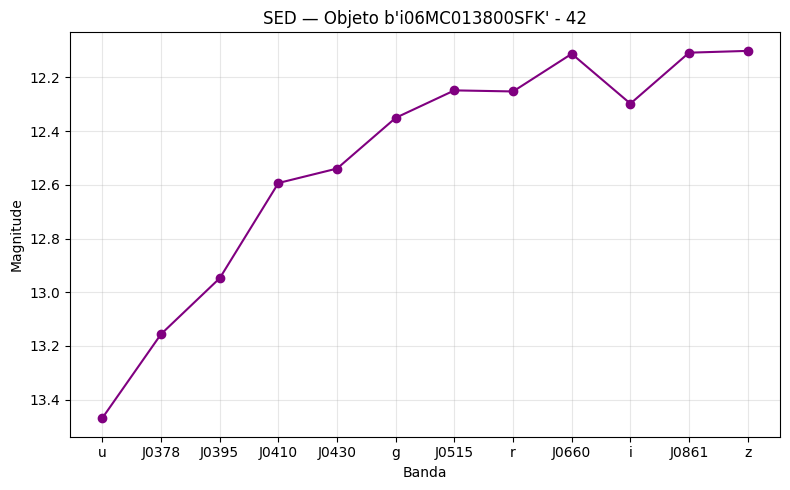

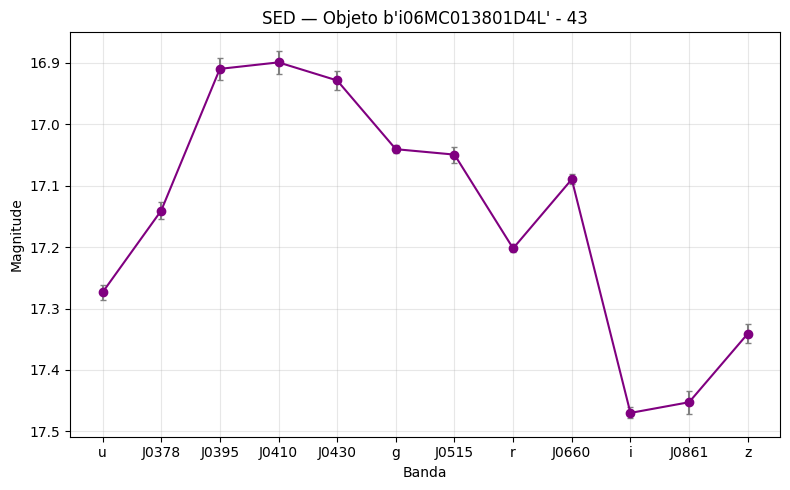

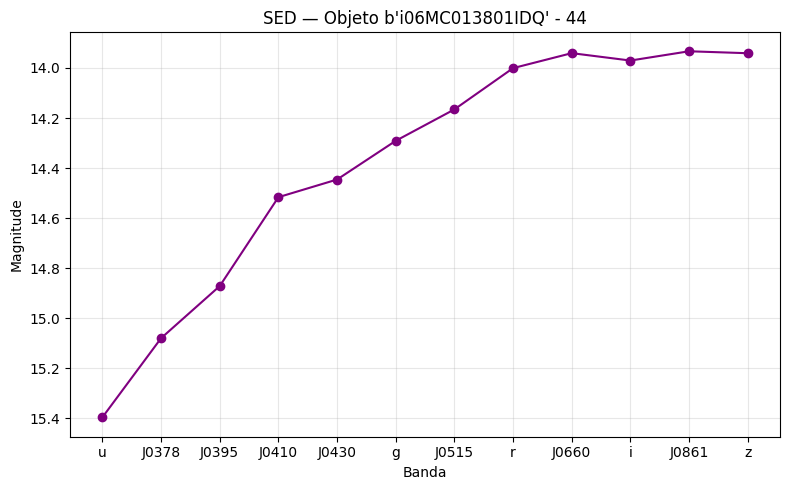

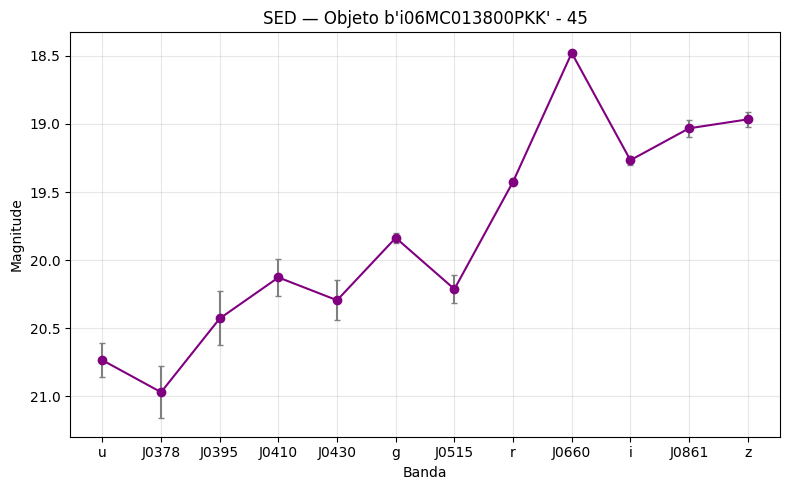

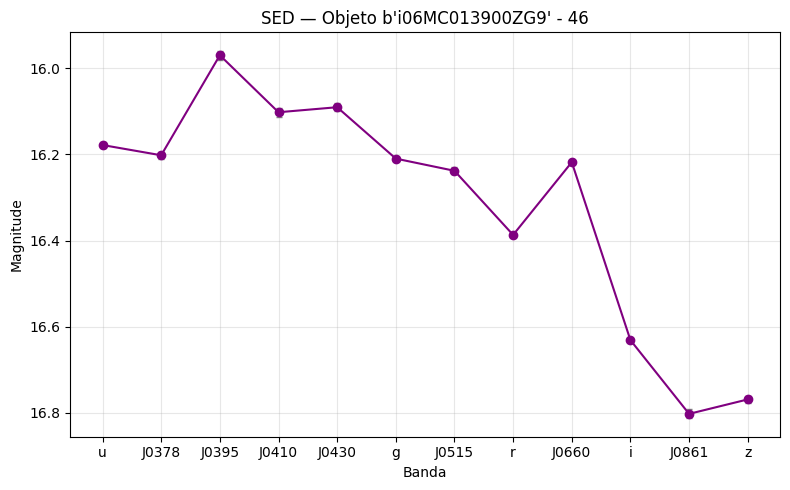

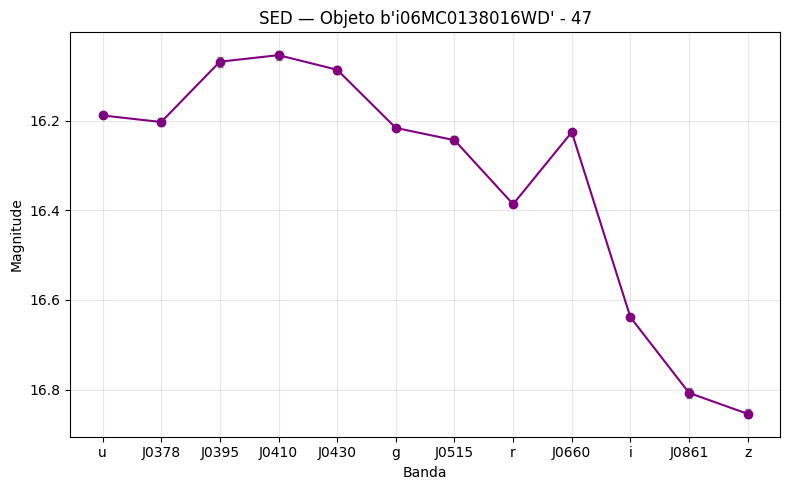

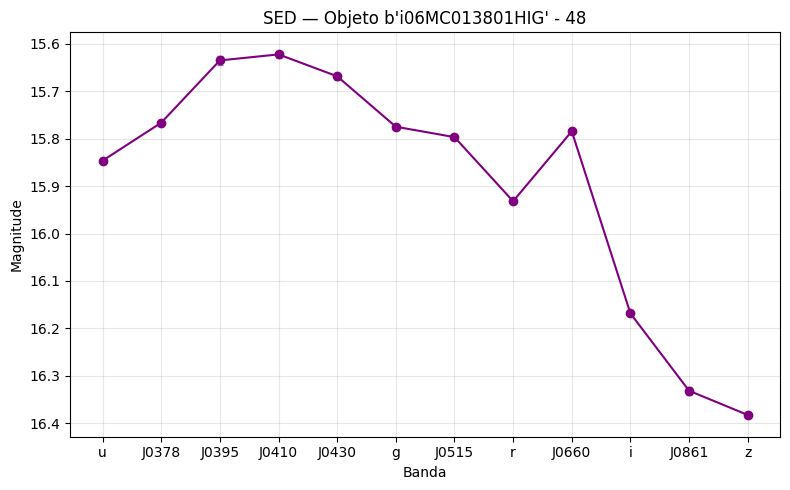

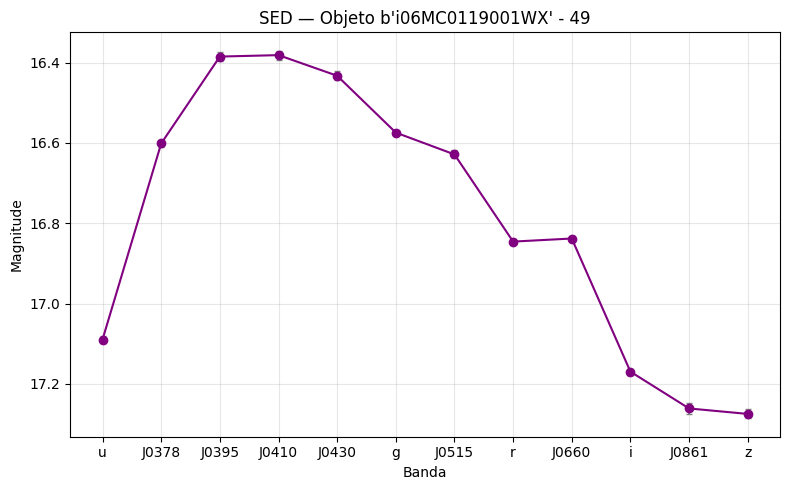

In [49]:
import numpy as np
import matplotlib.pyplot as plt

bands = ['u', 'J0378', 'J0395', 'J0410', 'J0430', 'g', 'J0515', 'r', 'J0660', 'i', 'J0861', 'z']
wavelengths = np.array([3536, 3770, 3940, 4094, 4292, 4751, 5133, 6258, 6614, 7690, 8611, 8831])

mag_cols = [f"star_mag_psf_{b.lower()}" for b in bands]
err_cols = [f"star_err_mag_psf_{b.lower()}" for b in bands]
has_errors = all(col in bica1.columns for col in err_cols)

i = 0
for idx, row in bica1.iterrows():
    mags = row[mag_cols].to_numpy()

    plt.figure(figsize=(8, 5))
    if has_errors:
        errs = row[err_cols].to_numpy()
        plt.errorbar(bands, mags, yerr=errs, fmt='o-', color='purple', ecolor='gray', capsize=2)
    else:
        plt.plot(bands, mags, 'o-', color='purple')

    plt.gca().invert_yaxis()
    plt.xlabel('Banda')
    plt.ylabel('Magnitude')
    plt.title(f'SED — Objeto {row["star_id"]} - {i}')  # <<< usar a linha atual
    # plt.title(f'SED — Objeto {row['id']} - {row['main_type']}')  # se quiser incluir o tipo

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    i += 1
    if i >= 50:
        break

In [50]:
bica1.to_csv('bica1_halpha_emitters.csv', index=False)

In [1]:
import pandas as pd
bica1 = pd.read_csv('bica1_halpha_emitters.csv')

In [8]:
import adss

client = adss.ADSSClient(base_url="https://ai-scope.cbpf.br")

In [9]:
metadata = client.get_database_metadata()

schema = metadata.get_schema("public")
for table in schema.tables:
    if "gaia" in table.name or "desi" in table.name:
        print(f"Table: {table.name}")

Table: gaia_spec_continuous_dr3
Table: gaia_dr3


In [36]:
ra = hw2['star_ra'].iloc[1]
dec = hw2['star_dec'].iloc[1]

In [33]:
hw2

,cluster_index,star_index,sep_arcsec,sep_arcmin,cluster_ra_deg,cluster_dec_deg,cluster_amaj,cluster_Names,star_ra,star_dec,...,star_mag_psf_j0395,star_mag_psf_j0410,star_mag_psf_j0430,star_mag_psf_g,star_mag_psf_j0515,star_mag_psf_r,star_mag_psf_j0660,star_mag_psf_i,star_mag_psf_j0861,star_mag_psf_z
70,3133,9851,1.416603,0.023610,6.987083,-74.001111,0.95,HW2,6.985787,-74.000946,...,18.879057,18.751524,18.615591,18.467764,18.282920,17.980234,17.729683,17.720509,17.493849,17.461987
3990,3133,3038,28.373360,0.472889,6.987083,-74.001111,0.95,HW2,6.973319,-74.008020,...,15.160406,15.234369,15.286059,15.405728,15.386243,15.445659,15.209139,15.586363,15.827524,15.823598
4031,3133,1001,28.538427,0.475640,6.987083,-74.001111,0.95,HW2,6.973642,-74.008120,...,15.191854,15.220327,15.270093,15.393486,15.387080,15.449656,15.186580,15.576020,15.824592,15.838327
4099,3133,9849,28.951128,0.482519,6.987083,-74.001111,0.95,HW2,6.973235,-74.008190,...,15.225813,15.279203,15.267191,15.426265,15.411190,15.478636,15.227413,15.603044,15.823457,15.834373


In [31]:
ra

6.9733195

In [32]:
dec

-74.00802

In [37]:
res = client.query(f"""select 
g.source_id, g.ra, g.dec,
g.parallax, g.phot_g_mean_mag, g.phot_bp_mean_mag, g.phot_rp_mean_mag,
g.phot_rp_mean_flux, g.phot_bp_mean_flux, g.phot_g_mean_flux,
s.bp_n_parameters, s.bp_standard_deviation, s.rp_n_parameters, s.rp_standard_deviation,
s.bp_coefficient_errors, s.bp_coefficient_correlations, s.rp_coefficient_errors, s.rp_coefficient_correlations,
s.bp_coefficients, s.rp_coefficients
FROM "public"."gaia_dr3" as g
join "public"."gaia_spec_continuous_dr3" as s
on g.source_id = s.source_id
where g.has_xp_continuous = true and cone(ra, dec, {ra}, {dec}, 0.001)
""",
mode = "astroql"
)

df = res.data
df.head()

,source_id,ra,dec,parallax,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,phot_rp_mean_flux,phot_bp_mean_flux,phot_g_mean_flux,bp_n_parameters,bp_standard_deviation,rp_n_parameters,rp_standard_deviation,bp_coefficient_errors,bp_coefficient_correlations,rp_coefficient_errors,rp_coefficient_correlations,bp_coefficients,rp_coefficients
0,4688427330144831232,6.973296,-74.008123,-0.065538,15.325397,15.326041,15.248545,6305.801832,10115.805903,13956.862802,55,1.210119,55,1.286239,"[1.3291252, 1.2250768, 1.2227924, 1.2650292, 1...","[0.067185044, -0.099666394, 0.021381427, -0.05...","[0.73696536, 0.69616127, 0.6754687, 0.7781682,...","[-0.18711181, 0.15231496, 0.2286163, -0.032364...","[1001.7251736038886, -421.5973745901938, 146.0...","[589.976903434018, -176.12010899942211, -16.25..."


In [38]:
from gaiaxpy import calibrate

calibrated_spectra, sampling = calibrate(df)

/home/marina/miniconda3/lib/python3.12/site-packages/gaiaxpy/output/sampled_spectra_data.py:113: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  modified_data = data.applymap(lambda x: _array_to_standard(x) if isinstance(x, ndarray) else x)


Default sampling


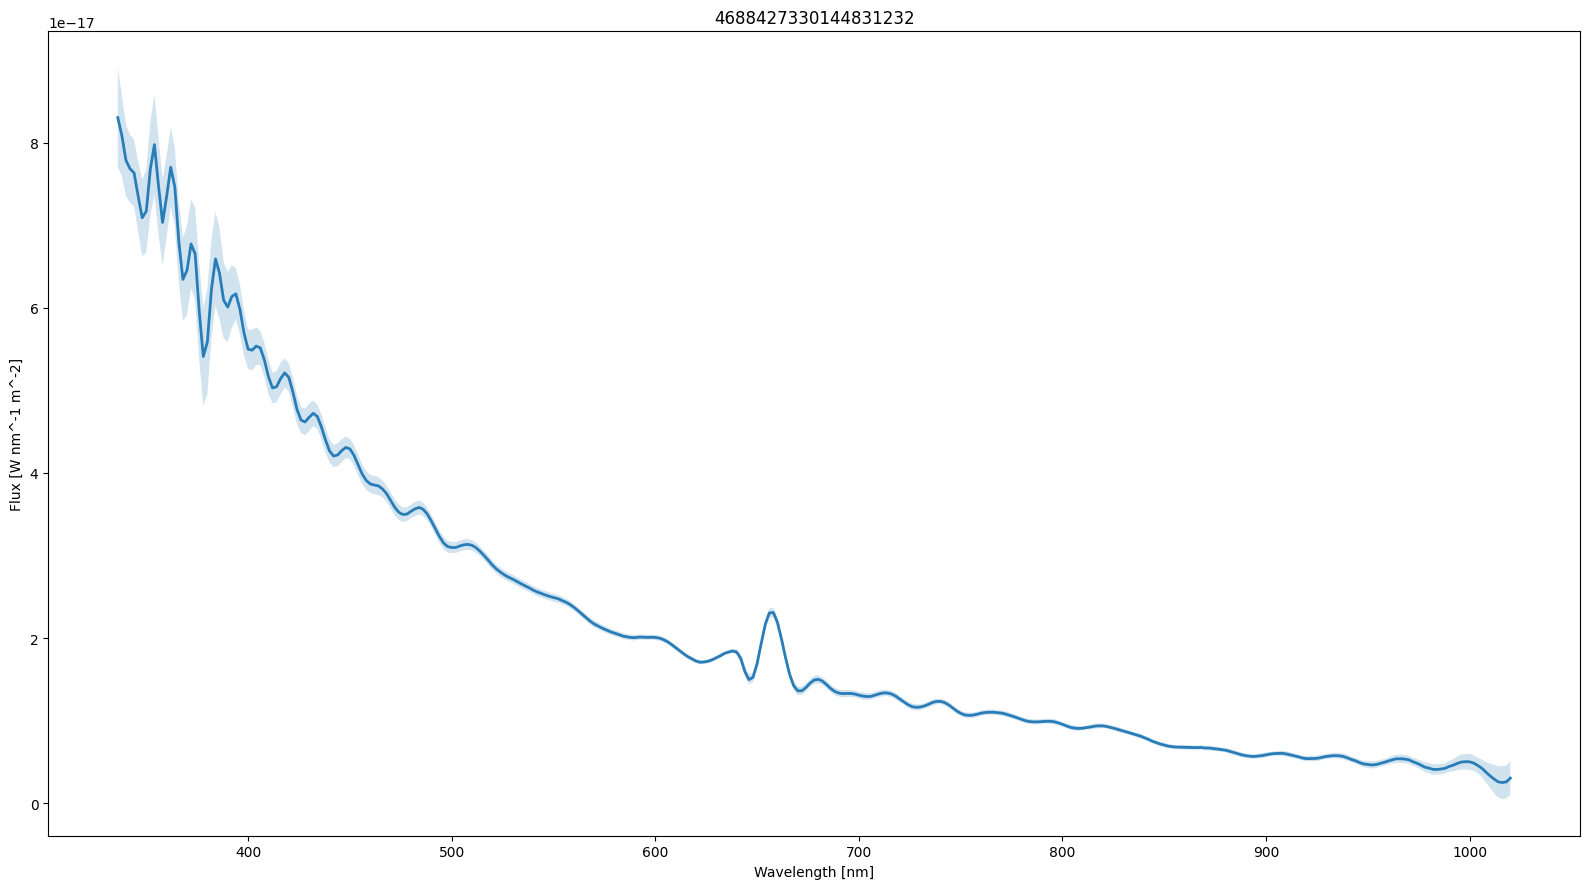

In [39]:

from gaiaxpy import plot_spectra

first_spectra = calibrated_spectra.iloc[0]

print('Default sampling')
# Do not show the legend as there's only one source in the data
plot_spectra(first_spectra, sampling=sampling, legend=False)

In [37]:
bica1

,cluster_index,star_index,sep_arcsec,sep_arcmin,cluster_ra_deg,cluster_dec_deg,cluster_amaj,cluster_Names,star_ra,star_dec,...,star_mag_psf_j0395,star_mag_psf_j0410,star_mag_psf_j0430,star_mag_psf_g,star_mag_psf_j0515,star_mag_psf_r,star_mag_psf_j0660,star_mag_psf_i,star_mag_psf_j0861,star_mag_psf_z
0,5736,18816,76.786006,1.279767,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",31.973112,-74.43748,...,13.718497,13.185256,13.128447,12.734455,12.606196,12.307721,12.252529,12.385682,12.165252,12.160000
1,5736,18819,189.700076,3.161668,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",32.072346,-74.39390,...,15.544681,15.564976,15.606739,15.693672,15.735846,15.869580,15.640634,16.063890,16.261196,16.272860
2,5736,18817,203.302613,3.388377,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",31.913400,-74.40224,...,16.939173,16.936700,16.954601,17.040033,17.093096,17.170261,16.935402,17.379133,17.539260,17.577736
3,5736,18814,226.499838,3.774997,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",32.243880,-74.41246,...,17.035220,16.985079,17.014406,17.139692,17.217192,17.380962,17.325367,17.608025,17.763765,17.851694
4,5736,18815,261.136954,4.352283,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",32.281204,-74.41048,...,16.638187,16.637846,16.648817,16.761658,16.797306,16.922565,16.693134,17.104740,17.320362,17.349552
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1040,5736,23634,7166.851852,119.447531,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",28.820267,-72.67620,...,17.262962,16.632736,16.570543,16.086231,15.926118,15.439963,15.313627,15.257951,15.111448,15.161289
1041,5736,44935,7167.639687,119.460661,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",24.610338,-74.66871,...,19.064184,18.614532,18.590887,18.384180,18.233480,18.028656,17.848630,17.958683,17.865513,17.952934
1042,5736,19322,7170.852849,119.514214,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",25.458641,-73.61607,...,17.450663,17.416380,17.501831,17.597002,17.618940,17.801926,17.721510,18.059685,18.162312,18.225597
1043,5736,695,7185.245890,119.754098,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",39.500270,-74.47616,...,14.333851,13.725114,13.623662,13.208361,13.017140,12.726866,12.662266,12.619847,12.521900,12.547705
